In [ ]:
# Cell 1 — Cek GPU
!nvidia-smi

Wed Jul 15 06:53:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# Cell 2 — Cek RAM dan Disk Colab
!free -h
!df -h

               total        used        free      shared  buff/cache   available
Mem:           176Gi       1.2Gi       172Gi       2.0Mi       3.6Gi       174Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /
tmpfs            64M     0   64M   0% /dev
shm              87G     0   87G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/nvme0n1p1  119G   52G   68G  44% /opt/bin/.nvidia
tmpfs            89G   80K   89G   1% /var/colab
tmpfs            89G     0   89G   0% /proc/acpi
tmpfs            89G     0   89G   0% /proc/scsi
tmpfs            89G     0   89G   0% /sys/firmware


In [ ]:
# Cell 3 — Install Ultralytics YOLO
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.5 MB/s eta 0:00:00


In [1]:
# Cell 4 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 5 — Konfigurasi Utama Revisi
from pathlib import Path
import os
import shutil
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# KONFIGURASI FILE DAN FOLDER
# ==========================================================

# Dataset ZIP tetap dibaca dari Google Drive
ZIP_PATH = Path("/content/drive/MyDrive/Colab Notebooks/Dataset_Tomat_YOLO.zip")

# Dataset hasil extract disimpan di lokal Colab
WORK_DIR = Path("/content/tomat_dataset")

# Semua hasil training/evaluasi disimpan di lokal Colab, bukan Drive
RESULT_DIR = Path("/content/YOLO_Tomat_Result")

# Nama run baru agar tidak tercampur dengan coba sebelumnya
RUN_NAME = "final_yolo11m_tomat_11class_hardaug_v2"

RUN_DIR = RESULT_DIR / RUN_NAME
ARTIFACT_DIR = RESULT_DIR / f"{RUN_NAME}_artifacts"

# ==========================================================
# KELAS DATASET TERBARU 11 KELAS
# ==========================================================
# Urutan ini harus sama dengan split_dataset_yolo.py dan data.yaml:
# 0  bacterial_spot_leaf
# 1  early_blight_leaf
# 2  healthy_leaf
# 3  late_blight_leaf
# 4  mosaic_virus
# 5  septoria_leaf_spot
# 6  bacterial_spot_fruit
# 7  blossom_end_rot
# 8  catface
# 9  healthy_fruit
# 10 serangan_hama

class_names = [
    "bacterial_spot_leaf",
    "early_blight_leaf",
    "healthy_leaf",
    "late_blight_leaf",
    "mosaic_virus",
    "septoria_leaf_spot",
    "bacterial_spot_fruit",
    "blossom_end_rot",
    "catface",
    "healthy_fruit",
    "serangan_hama"
]

# ==========================================================
# PARAMETER TRAINING
# ==========================================================
# Fokus percobaan ini:
# - bacterial_spot_leaf sudah ditambah data
# - early_blight_leaf dan late_blight_leaf dibantu dengan augmentasi train-only
# - training dibuat lebih stabil agar ciri bercak tidak terlalu rusak

MODEL_NAME = "yolo11m.pt"

EPOCHS = 160
IMGSZ = 832
BATCH = -1
WORKERS = 4
PATIENCE = 35
SEED = 42

# Jangan resume dari run lama karena strategi training berubah
RESUME_IF_AVAILABLE = False

# ==========================================================
# BUAT FOLDER LOKAL COLAB
# ==========================================================

RESULT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("ZIP_PATH:", ZIP_PATH)
print("WORK_DIR:", WORK_DIR)
print("RESULT_DIR:", RESULT_DIR)
print("RUN_DIR:", RUN_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("MODEL_NAME:", MODEL_NAME)
print("EPOCHS:", EPOCHS)
print("IMGSZ:", IMGSZ)
print("BATCH:", BATCH)
print("WORKERS:", WORKERS)
print("PATIENCE:", PATIENCE)
print("Jumlah kelas:", len(class_names))

print("\nDaftar kelas:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

ZIP_PATH: /content/drive/MyDrive/Colab Notebooks/Dataset_Tomat_YOLO.zip
WORK_DIR: /content/tomat_dataset
RESULT_DIR: /content/YOLO_Tomat_Result
RUN_DIR: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2
ARTIFACT_DIR: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts
MODEL_NAME: yolo11m.pt
EPOCHS: 160
IMGSZ: 832
BATCH: -1
WORKERS: 4
PATIENCE: 35
Jumlah kelas: 11

Daftar kelas:
0: bacterial_spot_leaf
1: early_blight_leaf
2: healthy_leaf
3: late_blight_leaf
4: mosaic_virus
5: septoria_leaf_spot
6: bacterial_spot_fruit
7: blossom_end_rot
8: catface
9: healthy_fruit
10: serangan_hama


In [ ]:
# Cell 6 — Cek File ZIP Dataset di Drive
print("Apakah file ZIP ada?", ZIP_PATH.exists())
print("Lokasi ZIP:", ZIP_PATH)

if ZIP_PATH.exists():
    print("Ukuran file:", round(ZIP_PATH.stat().st_size / (1024**3), 2), "GB")
else:
    raise FileNotFoundError(
        "Dataset_Tomat_YOLO.zip tidak ditemukan. "
        "Pastikan file ada di /content/drive/MyDrive/Colab Notebooks/"
    )

Apakah file ZIP ada? True
Lokasi ZIP: /content/drive/MyDrive/Colab Notebooks/Dataset_Tomat_YOLO.zip
Ukuran file: 8.16 GB


In [4]:
# Cell 7 — Extract Dataset dari Drive ke Lokal Colab
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)

WORK_DIR.mkdir(parents=True, exist_ok=True)

shutil.unpack_archive(
    str(ZIP_PATH),
    str(WORK_DIR)
)

print("Dataset berhasil diekstrak ke:", WORK_DIR)

Dataset berhasil diekstrak ke: /content/tomat_dataset


In [5]:
# Cell 8 — Cari Lokasi Dataset YOLO
candidate_paths = [WORK_DIR]

for item in WORK_DIR.rglob("*"):
    if item.is_dir():
        candidate_paths.append(item)

dataset_path = None
data_yaml_path = None

for path in candidate_paths:
    data_yaml = path / "data.yaml"
    images_dir = path / "images"
    labels_dir = path / "labels"

    if data_yaml.exists() and images_dir.exists() and labels_dir.exists():
        dataset_path = path
        data_yaml_path = data_yaml
        break

if dataset_path is None:
    print("Dataset YOLO belum ditemukan.")
    print("Isi folder kerja:")
    for item in WORK_DIR.iterdir():
        print(item)
    raise FileNotFoundError("Struktur dataset YOLO tidak ditemukan.")
else:
    print("Dataset ditemukan di:")
    print(dataset_path)

    print("\nFile data.yaml:")
    print(data_yaml_path)

    print("\nIsi folder dataset:")
    for item in dataset_path.iterdir():
        print(item)

Dataset ditemukan di:
/content/tomat_dataset

File data.yaml:
/content/tomat_dataset/data.yaml

Isi folder dataset:
/content/tomat_dataset/images
/content/tomat_dataset/data.yaml
/content/tomat_dataset/labels


In [ ]:
# Cell 9 — Perbaiki data.yaml untuk 11 Kelas
data_yaml_path = dataset_path / "data.yaml"

yaml_text = f"""
path: {dataset_path}
train: images/train
val: images/val
test: images/test

nc: {len(class_names)}
names:
"""

for i, name in enumerate(class_names):
    yaml_text += f"  {i}: {name}\n"

data_yaml_path.write_text(yaml_text)

print("Isi data.yaml terbaru:")
print(data_yaml_path.read_text())

Isi data.yaml terbaru:

path: /content/tomat_dataset
train: images/train
val: images/val
test: images/test

nc: 11
names:
  0: bacterial_spot_leaf
  1: early_blight_leaf
  2: healthy_leaf
  3: late_blight_leaf
  4: mosaic_virus
  5: septoria_leaf_spot
  6: bacterial_spot_fruit
  7: blossom_end_rot
  8: catface
  9: healthy_fruit
  10: serangan_hama



In [ ]:
# Cell 10 — Cek Jumlah Data Train, Val, Test
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def count_images(folder):
    total = 0

    if not folder.exists():
        return total

    for ext in image_extensions:
        total += len(list(folder.glob(f"*{ext}")))
        total += len(list(folder.glob(f"*{ext.upper()}")))

    return total


print("Rekap dataset YOLO:")

for split in ["train", "val", "test"]:
    image_dir = dataset_path / "images" / split
    label_dir = dataset_path / "labels" / split

    image_count = count_images(image_dir)
    label_count = len(list(label_dir.glob("*.txt"))) if label_dir.exists() else 0

    print(f"{split}: {image_count} gambar, {label_count} label")

Rekap dataset YOLO:
train: 2585 gambar, 2585 label
val: 319 gambar, 319 label
test: 330 gambar, 330 label


In [ ]:
# Cell 11 — Cek Distribusi Class ID
from collections import Counter

class_counter = Counter()
invalid_label_files = []

for split in ["train", "val", "test"]:
    label_dir = dataset_path / "labels" / split

    if not label_dir.exists():
        print(f"Folder label tidak ditemukan: {label_dir}")
        continue

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as f:
            for line_number, line in enumerate(f, start=1):
                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) != 5:
                    invalid_label_files.append((str(label_file), line_number, line))
                    continue

                try:
                    class_id = int(float(parts[0]))
                    class_counter[class_id] += 1
                except ValueError:
                    invalid_label_files.append((str(label_file), line_number, line))


print("Distribusi class ID:")

for class_id in sorted(class_counter.keys()):
    if 0 <= class_id < len(class_names):
        print(f"{class_id} - {class_names[class_id]}: {class_counter[class_id]}")
    else:
        print(f"{class_id} - CLASS ID TIDAK TERDAFTAR: {class_counter[class_id]}")

print("\nJumlah file/line label tidak valid:", len(invalid_label_files))

if len(invalid_label_files) > 0:
    print("\nContoh label tidak valid:")
    for item in invalid_label_files[:10]:
        print(item)

Distribusi class ID:
0 - bacterial_spot_leaf: 392
1 - early_blight_leaf: 473
2 - healthy_leaf: 460
3 - late_blight_leaf: 385
4 - mosaic_virus: 502
5 - septoria_leaf_spot: 321
6 - bacterial_spot_fruit: 317
7 - blossom_end_rot: 294
8 - catface: 294
9 - healthy_fruit: 367
10 - serangan_hama: 297

Jumlah file/line label tidak valid: 0


In [ ]:
# Cell 12 — Pastikan Semua Gambar Format RGB
from PIL import Image
from collections import Counter

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

CONVERT_TO_RGB = True

mode_counter = Counter()
non_rgb_files = []
error_image_files = []

for split in ["train", "val", "test"]:
    image_dir = dataset_path / "images" / split

    if not image_dir.exists():
        print(f"Folder gambar tidak ditemukan: {image_dir}")
        continue

    for image_path in image_dir.iterdir():
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        try:
            with Image.open(image_path) as img:
                mode_counter[img.mode] += 1

                if img.mode != "RGB":
                    non_rgb_files.append((str(image_path), img.mode))

                    if CONVERT_TO_RGB:
                        rgb_img = img.convert("RGB")
                        rgb_img.save(image_path)

        except Exception as e:
            error_image_files.append((str(image_path), str(e)))


print("Distribusi mode warna gambar:")

for mode, count in mode_counter.items():
    print(f"{mode}: {count}")

print("\nJumlah gambar non-RGB ditemukan:", len(non_rgb_files))

if len(non_rgb_files) > 0:
    print("\nContoh gambar non-RGB:")
    for item in non_rgb_files[:10]:
        print(item)

    print("\nGambar non-RGB sudah dikonversi ke RGB di folder kerja Colab.")
else:
    print("\nSemua gambar sudah dalam format RGB.")

print("\nJumlah gambar error:", len(error_image_files))

if len(error_image_files) > 0:
    print("\nContoh gambar error:")
    for item in error_image_files[:10]:
        print(item)

Distribusi mode warna gambar:
RGB: 3234

Jumlah gambar non-RGB ditemukan: 0

Semua gambar sudah dalam format RGB.

Jumlah gambar error: 0


In [ ]:
# Cell 12B — Augmentasi Train-Only untuk Kelas Sulit
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps
import random
from collections import Counter

random.seed(SEED)

train_images_dir = dataset_path / "images" / "train"
train_labels_dir = dataset_path / "labels" / "train"

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

HARD_CLASS_NAMES = [
    "bacterial_spot_leaf",
    "early_blight_leaf",
    "late_blight_leaf"
]

CLASS_ID_BY_NAME = {name: idx for idx, name in enumerate(class_names)}

# Target objek train untuk kelas sulit.
# Bisa disesuaikan kalau terlalu banyak.
TARGET_TRAIN_OBJECTS = {
    "bacterial_spot_leaf": 672,
    "early_blight_leaf": 756,
    "late_blight_leaf": 672
}


def find_image_by_stem_local(image_dir, stem):
    for ext in IMAGE_EXTENSIONS:
        p = image_dir / f"{stem}{ext}"
        if p.exists():
            return p

        p_upper = image_dir / f"{stem}{ext.upper()}"
        if p_upper.exists():
            return p_upper

    return None


def read_yolo_label_file(label_path):
    labels = []

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            labels.append([class_id, x_center, y_center, width, height])

    return labels


def write_yolo_label_file(label_path, labels):
    with open(label_path, "w", encoding="utf-8") as f:
        for label in labels:
            class_id, x_center, y_center, width, height = label

            f.write(
                f"{int(class_id)} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{width:.6f} "
                f"{height:.6f}\n"
            )


def horizontal_flip_labels(labels):
    new_labels = []

    for label in labels:
        class_id, x_center, y_center, width, height = label
        new_x_center = 1.0 - x_center
        new_labels.append([class_id, new_x_center, y_center, width, height])

    return new_labels


def augment_image_and_labels(image_path, labels):
    with Image.open(image_path) as img:
        img = ImageOps.exif_transpose(img).convert("RGB")

    aug_type = random.choice([
        "hflip",
        "brightness",
        "contrast",
        "sharpness",
        "color"
    ])

    new_labels = [label.copy() for label in labels]

    if aug_type == "hflip":
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
        new_labels = horizontal_flip_labels(new_labels)

    elif aug_type == "brightness":
        factor = random.uniform(0.90, 1.10)
        img = ImageEnhance.Brightness(img).enhance(factor)

    elif aug_type == "contrast":
        factor = random.uniform(0.90, 1.12)
        img = ImageEnhance.Contrast(img).enhance(factor)

    elif aug_type == "sharpness":
        factor = random.uniform(0.90, 1.20)
        img = ImageEnhance.Sharpness(img).enhance(factor)

    elif aug_type == "color":
        factor = random.uniform(0.90, 1.10)
        img = ImageEnhance.Color(img).enhance(factor)

    return img, new_labels, aug_type


def count_objects_per_class(label_dir):
    counter = Counter()

    for label_path in label_dir.glob("*.txt"):
        labels = read_yolo_label_file(label_path)

        for label in labels:
            counter[label[0]] += 1

    return counter


def collect_train_pairs_for_class(target_class_id):
    pairs = []

    for label_path in train_labels_dir.glob("*.txt"):
        image_path = find_image_by_stem_local(train_images_dir, label_path.stem)

        if image_path is None:
            continue

        labels = read_yolo_label_file(label_path)

        if any(label[0] == target_class_id for label in labels):
            pairs.append((image_path, label_path, labels))

    return pairs


print("Distribusi objek train sebelum augmentasi:")

before_counter = count_objects_per_class(train_labels_dir)

for class_id, class_name in enumerate(class_names):
    print(f"{class_id:>2} - {class_name:<25}: {before_counter.get(class_id, 0)}")


for class_name in HARD_CLASS_NAMES:
    class_id = CLASS_ID_BY_NAME[class_name]
    target_count = TARGET_TRAIN_OBJECTS[class_name]

    current_counter = count_objects_per_class(train_labels_dir)
    current_count = current_counter.get(class_id, 0)

    pairs = collect_train_pairs_for_class(class_id)

    print("\n" + "-" * 70)
    print(f"Kelas diperkuat : {class_name}")
    print(f"Class ID        : {class_id}")
    print(f"Jumlah sekarang : {current_count}")
    print(f"Target train    : {target_count}")
    print(f"Jumlah sumber   : {len(pairs)}")

    if len(pairs) == 0:
        print("Tidak ada data sumber. Kelas dilewati.")
        continue

    aug_index = 1

    while current_count < target_count:
        image_path, label_path, labels = random.choice(pairs)

        aug_img, aug_labels, aug_type = augment_image_and_labels(
            image_path=image_path,
            labels=labels
        )

        new_stem = f"hardaug_{class_name}_{aug_index:05d}_{aug_type}_{image_path.stem}"

        new_image_path = train_images_dir / f"{new_stem}.jpg"
        new_label_path = train_labels_dir / f"{new_stem}.txt"

        aug_img.save(new_image_path, quality=95)
        write_yolo_label_file(new_label_path, aug_labels)

        current_count += sum(1 for label in aug_labels if label[0] == class_id)
        aug_index += 1

    print(f"Jumlah akhir train {class_name}: {current_count}")


print("\nDistribusi objek train setelah augmentasi:")

after_counter = count_objects_per_class(train_labels_dir)

for class_id, class_name in enumerate(class_names):
    print(f"{class_id:>2} - {class_name:<25}: {after_counter.get(class_id, 0)}")

Distribusi objek train sebelum augmentasi:
 0 - bacterial_spot_leaf      : 307
 1 - early_blight_leaf        : 372
 2 - healthy_leaf             : 360
 3 - late_blight_leaf         : 305
 4 - mosaic_virus             : 397
 5 - septoria_leaf_spot       : 260
 6 - bacterial_spot_fruit     : 253
 7 - blossom_end_rot          : 235
 8 - catface                  : 235
 9 - healthy_fruit            : 291
10 - serangan_hama            : 238

----------------------------------------------------------------------
Kelas diperkuat : bacterial_spot_leaf
Class ID        : 0
Jumlah sekarang : 307
Target train    : 672
Jumlah sumber   : 235
Jumlah akhir train bacterial_spot_leaf: 672

----------------------------------------------------------------------
Kelas diperkuat : early_blight_leaf
Class ID        : 1
Jumlah sekarang : 372
Target train    : 756
Jumlah sumber   : 235
Jumlah akhir train early_blight_leaf: 756

----------------------------------------------------------------------
Kelas diperku

In [ ]:
# Cell 13 — Training YOLOv11 dengan Augmentasi Lebih Stabil
from ultralytics import YOLO

last_model_path = RUN_DIR / "weights" / "last.pt"

print("Folder training:", RUN_DIR)
print("Checkpoint last.pt:", last_model_path)
print("Apakah last.pt tersedia?", last_model_path.exists())
print("Jumlah kelas training:", len(class_names))

if RESUME_IF_AVAILABLE and last_model_path.exists():
    print("Melanjutkan training dari last.pt...")
    model = YOLO(str(last_model_path))
    results = model.train(resume=True)

else:
    print("Memulai training baru dengan model:", MODEL_NAME)
    model = YOLO(MODEL_NAME)

    results = model.train(
        data=str(data_yaml_path),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        workers=WORKERS,
        device=0,

        project=str(RESULT_DIR),
        name=RUN_NAME,
        exist_ok=True,

        optimizer="AdamW",
        lr0=0.0007,
        lrf=0.01,
        momentum=0.937,
        weight_decay=0.0005,
        warmup_epochs=3,

        seed=SEED,
        deterministic=True,

        save=True,
        save_period=1,
        patience=PATIENCE,

        close_mosaic=25,
        hsv_h=0.008,
        hsv_s=0.30,
        hsv_v=0.22,
        degrees=2,
        translate=0.06,
        scale=0.25,
        fliplr=0.50,
        mosaic=0.50,
        mixup=0.0,
        copy_paste=0.0,

        plots=True,
        verbose=True
    )

print("Training selesai atau checkpoint tersimpan.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Folder training: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2
Checkpoint last.pt: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2/weights/last.pt
Apakah last.pt tersedia? False
Jumlah kelas training: 11
Memulai training baru dengan model: yolo11m.pt
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=25, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, 

In [ ]:
# Cell 14 — Simpan best.pt dan last.pt ke Folder Artifact Colab
from ultralytics import YOLO
import shutil

weights_dir = RUN_DIR / "weights"

best_model_path = weights_dir / "best.pt"
last_model_path = weights_dir / "last.pt"

print("best.pt:", best_model_path, best_model_path.exists())
print("last.pt:", last_model_path, last_model_path.exists())

if not best_model_path.exists():
    raise FileNotFoundError(
        "best.pt belum ditemukan. "
        "Pastikan training sudah selesai minimal beberapa epoch."
    )

artifact_best_path = ARTIFACT_DIR / "best.pt"
artifact_last_path = ARTIFACT_DIR / "last.pt"

shutil.copy2(best_model_path, artifact_best_path)

if last_model_path.exists():
    shutil.copy2(last_model_path, artifact_last_path)

print("best.pt tersimpan di:", artifact_best_path)
print("last.pt tersimpan di:", artifact_last_path if last_model_path.exists() else "last.pt tidak ditemukan")

model = YOLO(str(best_model_path))

best.pt: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2/weights/best.pt True
last.pt: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2/weights/last.pt True
best.pt tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/best.pt
last.pt tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/last.pt


In [ ]:
# Cell 15 — Fungsi Evaluasi: IoU, Precision, Recall, mAP50, mAP50-95
from pathlib import Path
from PIL import Image
from collections import defaultdict
import numpy as np
import pandas as pd

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]


def find_image_by_stem(image_dir, stem):
    for ext in IMAGE_EXTENSIONS:
        path = image_dir / f"{stem}{ext}"
        if path.exists():
            return path

        path_upper = image_dir / f"{stem}{ext.upper()}"
        if path_upper.exists():
            return path_upper

    return None


def yolo_to_xyxy(x_center, y_center, box_width, box_height, img_width, img_height):
    x1 = (x_center - box_width / 2) * img_width
    y1 = (y_center - box_height / 2) * img_height
    x2 = (x_center + box_width / 2) * img_width
    y2 = (y_center + box_height / 2) * img_height

    return np.array([x1, y1, x2, y2], dtype=np.float32)


def box_iou(box_a, box_b):
    xA = max(box_a[0], box_b[0])
    yA = max(box_a[1], box_b[1])
    xB = min(box_a[2], box_b[2])
    yB = min(box_a[3], box_b[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    area_a = max(0, box_a[2] - box_a[0]) * max(0, box_a[3] - box_a[1])
    area_b = max(0, box_b[2] - box_b[0]) * max(0, box_b[3] - box_b[1])

    union_area = area_a + area_b - inter_area

    if union_area == 0:
        return 0.0

    return inter_area / union_area


def compute_mean_iou_per_class(split_name, conf_threshold=0.20, iou_match_threshold=0.5):
    image_dir = dataset_path / "images" / split_name
    label_dir = dataset_path / "labels" / split_name

    iou_values_per_class = defaultdict(list)

    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files += list(image_dir.glob(f"*{ext}"))
        image_files += list(image_dir.glob(f"*{ext.upper()}"))

    for image_path in image_files:
        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            continue

        with Image.open(image_path) as img:
            img_width, img_height = img.size

        gt_boxes = []

        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) != 5:
                    continue

                class_id = int(float(parts[0]))

                if class_id < 0 or class_id >= len(class_names):
                    continue

                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])

                xyxy = yolo_to_xyxy(
                    x_center,
                    y_center,
                    box_width,
                    box_height,
                    img_width,
                    img_height
                )

                gt_boxes.append({
                    "class_id": class_id,
                    "box": xyxy
                })

        if len(gt_boxes) == 0:
            continue

        pred_results = model.predict(
            source=str(image_path),
            imgsz=IMGSZ,
            conf=conf_threshold,
            verbose=False,
            device=0
        )

        result = pred_results[0]

        if result.boxes is None or len(result.boxes) == 0:
            continue

        pred_xyxy = result.boxes.xyxy.cpu().numpy()
        pred_cls = result.boxes.cls.cpu().numpy().astype(int)

        used_pred_indices = set()

        for gt in gt_boxes:
            gt_class = gt["class_id"]
            gt_box = gt["box"]

            best_iou = 0.0
            best_pred_index = None

            for pred_index, pred_box in enumerate(pred_xyxy):
                if pred_index in used_pred_indices:
                    continue

                if pred_cls[pred_index] != gt_class:
                    continue

                current_iou = box_iou(gt_box, pred_box)

                if current_iou > best_iou:
                    best_iou = current_iou
                    best_pred_index = pred_index

            if best_pred_index is not None and best_iou >= iou_match_threshold:
                used_pred_indices.add(best_pred_index)
                iou_values_per_class[gt_class].append(best_iou)

    rows = []

    for class_id, class_name in enumerate(class_names):
        values = iou_values_per_class[class_id]

        if len(values) > 0:
            mean_iou = float(np.mean(values))
            matched_count = len(values)
        else:
            mean_iou = np.nan
            matched_count = 0

        rows.append({
            "Dataset": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "IoU": mean_iou,
            "matched_objects": matched_count
        })

    return pd.DataFrame(rows)


def extract_per_class_metrics(metrics, split_name):
    n_classes = len(class_names)

    precision_arr = np.full(n_classes, np.nan)
    recall_arr = np.full(n_classes, np.nan)
    map50_arr = np.full(n_classes, np.nan)
    map50_95_arr = np.full(n_classes, np.nan)

    box = metrics.box

    ap_class_index = getattr(box, "ap_class_index", None)

    if ap_class_index is None:
        ap_class_index = np.arange(n_classes)
    else:
        ap_class_index = np.array(ap_class_index).astype(int)

    for pos, class_id in enumerate(ap_class_index):
        if class_id >= n_classes:
            continue

        try:
            p, r, ap50, ap = box.class_result(pos)
            precision_arr[class_id] = p
            recall_arr[class_id] = r
            map50_arr[class_id] = ap50
            map50_95_arr[class_id] = ap
        except Exception:
            pass

    rows = []

    for class_id, class_name in enumerate(class_names):
        rows.append({
            "Dataset": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "Precision": precision_arr[class_id],
            "Recall": recall_arr[class_id],
            "mAP50": map50_arr[class_id],
            "mAP50-95": map50_95_arr[class_id]
        })

    return pd.DataFrame(rows)


def evaluate_split(split_name):
    print(f"\nEvaluasi dataset: {split_name}")

    metrics = model.val(
        data=str(data_yaml_path),
        split=split_name,
        imgsz=IMGSZ,
        device=0,
        project=str(RESULT_DIR),
        name=f"evaluasi_{split_name}_{RUN_NAME}",
        exist_ok=True,
        plots=True
    )

    per_class_df = extract_per_class_metrics(metrics, split_name)

    iou_df = compute_mean_iou_per_class(
        split_name=split_name,
        conf_threshold=0.20,
        iou_match_threshold=0.5
    )

    per_class_df = per_class_df.merge(
        iou_df,
        on=["Dataset", "class_id", "class_name"],
        how="left"
    )

    per_class_df = per_class_df[
        [
            "Dataset",
            "class_id",
            "class_name",
            "IoU",
            "Precision",
            "Recall",
            "mAP50",
            "mAP50-95",
            "matched_objects"
        ]
    ]

    overall_row = {
        "Dataset": split_name,
        "IoU": float(per_class_df["IoU"].mean(skipna=True)),
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map)
    }

    return overall_row, per_class_df

In [ ]:
# Cell 16 — Jalankan Evaluasi Val dan Test
overall_val, per_class_val = evaluate_split("val")
overall_test, per_class_test = evaluate_split("test")

overall_df = pd.DataFrame([overall_val, overall_test])

overall_df = overall_df[
    [
        "Dataset",
        "IoU",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ]
]

per_class_metrics_df = pd.concat([per_class_val, per_class_test], ignore_index=True)

print("\nHasil evaluasi keseluruhan:")
display(overall_df)

print("\nHasil evaluasi per kelas:")
display(per_class_metrics_df)

overall_csv_path = ARTIFACT_DIR / "hasil_evaluasi_overall.csv"
per_class_csv_path = ARTIFACT_DIR / "hasil_evaluasi_perkelas.csv"

overall_df.to_csv(overall_csv_path, index=False)
per_class_metrics_df.to_csv(per_class_csv_path, index=False)

print("CSV overall tersimpan di:", overall_csv_path)
print("CSV per kelas tersimpan di:", per_class_csv_path)

In [41]:
# Cell 16B — Fungsi Perhitungan Manual IoU, Precision, Recall, mAP50, mAP50-95
from pathlib import Path
from PIL import Image
from collections import defaultdict
import numpy as np
import pandas as pd

MANUAL_CONF_THRESHOLD = 0.70
MANUAL_IOU_THRESHOLD = 0.50
MANUAL_PREDICTION_CONF = 0.001
MANUAL_AP_IOU_THRESHOLDS = np.round(np.arange(0.50, 0.96, 0.05), 2)


def manual_safe_divide(numerator, denominator):
    """Pembagian aman untuk menghindari ZeroDivisionError."""
    if denominator == 0:
        return np.nan
    return float(numerator / denominator)


def manual_read_ground_truth(image_path, label_path):
    """
    Membaca label YOLO:
    class_id x_center y_center width height
    lalu mengubahnya menjadi koordinat piksel [x1, y1, x2, y2].
    """
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    ground_truths = []

    if not label_path.exists():
        return ground_truths

    with open(label_path, "r", encoding="utf-8") as file:
        for line in file:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))

            if class_id < 0 or class_id >= len(class_names):
                continue

            x_center = float(parts[1])
            y_center = float(parts[2])
            box_width = float(parts[3])
            box_height = float(parts[4])

            box_xyxy = yolo_to_xyxy(
                x_center,
                y_center,
                box_width,
                box_height,
                img_width,
                img_height
            )

            # Batasi koordinat agar tetap berada di dalam gambar.
            box_xyxy[0] = np.clip(box_xyxy[0], 0, img_width)
            box_xyxy[1] = np.clip(box_xyxy[1], 0, img_height)
            box_xyxy[2] = np.clip(box_xyxy[2], 0, img_width)
            box_xyxy[3] = np.clip(box_xyxy[3], 0, img_height)

            ground_truths.append({
                "class_id": class_id,
                "box": box_xyxy
            })

    return ground_truths


def manual_collect_split_data(split_name):
    """
    Mengumpulkan ground truth dan prediksi untuk satu split.

    Prediksi dilakukan per gambar agar setiap hasil prediksi
    pasti dipasangkan dengan ground truth dari gambar yang sama.
    """
    image_dir = dataset_path / "images" / split_name
    label_dir = dataset_path / "labels" / split_name

    image_paths = []

    for extension in IMAGE_EXTENSIONS:
        image_paths.extend(image_dir.glob(f"*{extension}"))
        image_paths.extend(image_dir.glob(f"*{extension.upper()}"))

    image_paths = sorted(
        set(image_paths),
        key=lambda path: path.name.lower()
    )

    if len(image_paths) == 0:
        raise FileNotFoundError(
            f"Tidak ada gambar pada split: {split_name}"
        )

    gt_by_image = {}
    pred_by_image = {}

    for image_index, image_path in enumerate(image_paths, start=1):
        # Kunci yang sama digunakan untuk GT dan prediksi
        image_key = image_path.name
        label_path = label_dir / f"{image_path.stem}.txt"

        # Membaca ground truth
        gt_by_image[image_key] = manual_read_ground_truth(
            image_path=image_path,
            label_path=label_path
        )

        pred_by_image[image_key] = []

        # Prediksi dilakukan per gambar agar image_key tidak berubah
        prediction_results = model.predict(
            source=str(image_path),
            imgsz=IMGSZ,
            conf=MANUAL_PREDICTION_CONF,
            iou=0.70,
            max_det=300,
            device="cpu",
            verbose=False
        )

        result = prediction_results[0]

        if result.boxes is not None and len(result.boxes) > 0:
            boxes_xyxy = (
                result.boxes.xyxy
                .detach()
                .cpu()
                .numpy()
            )

            confidences = (
                result.boxes.conf
                .detach()
                .cpu()
                .numpy()
            )

            class_ids = (
                result.boxes.cls
                .detach()
                .cpu()
                .numpy()
                .astype(int)
            )

            for box_xyxy, confidence, class_id in zip(
                boxes_xyxy,
                confidences,
                class_ids
            ):
                if class_id < 0 or class_id >= len(class_names):
                    continue

                pred_by_image[image_key].append({
                    "class_id": int(class_id),
                    "confidence": float(confidence),
                    "box": box_xyxy.astype(np.float32)
                })

        if image_index % 50 == 0 or image_index == len(image_paths):
            print(
                f"{split_name}: "
                f"{image_index}/{len(image_paths)} gambar selesai"
            )

    # Pemeriksaan bahwa seluruh kunci gambar sesuai
    gt_keys = set(gt_by_image.keys())
    pred_keys = set(pred_by_image.keys())

    print(f"\nPemeriksaan split {split_name}:")
    print("Jumlah gambar GT       :", len(gt_keys))
    print("Jumlah gambar prediksi :", len(pred_keys))
    print("Kunci gambar sama      :", gt_keys == pred_keys)

    if gt_keys != pred_keys:
        print(
            "Prediksi tanpa GT:",
            list(pred_keys - gt_keys)[:10]
        )
        print(
            "GT tanpa prediksi:",
            list(gt_keys - pred_keys)[:10]
        )

    return gt_by_image, pred_by_image


def manual_match_one_class(
    gt_by_image,
    pred_by_image,
    class_id,
    iou_threshold,
    confidence_threshold
):
    """
    Mencocokkan prediksi dan ground truth untuk satu kelas.

    Urutan prediksi dibuat dari confidence tertinggi ke terendah.
    Satu ground truth hanya boleh dipasangkan dengan satu prediksi.
    """
    gt_boxes_by_image = {}
    total_gt = 0

    for image_key, ground_truths in gt_by_image.items():
        class_boxes = [
            item["box"]
            for item in ground_truths
            if item["class_id"] == class_id
        ]

        gt_boxes_by_image[image_key] = class_boxes
        total_gt += len(class_boxes)

    predictions = []

    for image_key, prediction_items in pred_by_image.items():
        for item in prediction_items:
            if (
                item["class_id"] == class_id
                and item["confidence"] >= confidence_threshold
            ):
                predictions.append({
                    "image_key": image_key,
                    "confidence": item["confidence"],
                    "box": item["box"]
                })

    predictions.sort(key=lambda item: item["confidence"], reverse=True)

    used_gt_indices = defaultdict(set)

    tp_flags = np.zeros(len(predictions), dtype=np.float64)
    fp_flags = np.zeros(len(predictions), dtype=np.float64)
    matched_ious = np.full(len(predictions), np.nan, dtype=np.float64)

    for prediction_index, prediction in enumerate(predictions):
        image_key = prediction["image_key"]
        predicted_box = prediction["box"]
        candidate_gt_boxes = gt_boxes_by_image.get(image_key, [])

        best_iou = 0.0
        best_gt_index = None

        for gt_index, gt_box in enumerate(candidate_gt_boxes):
            if gt_index in used_gt_indices[image_key]:
                continue

            current_iou = box_iou(predicted_box, gt_box)

            if current_iou > best_iou:
                best_iou = current_iou
                best_gt_index = gt_index

        if best_gt_index is not None and best_iou >= iou_threshold:
            tp_flags[prediction_index] = 1.0
            matched_ious[prediction_index] = best_iou
            used_gt_indices[image_key].add(best_gt_index)
        else:
            fp_flags[prediction_index] = 1.0

    confidences = np.array(
        [item["confidence"] for item in predictions],
        dtype=np.float64
    )

    return {
        "total_gt": total_gt,
        "total_predictions": len(predictions),
        "confidences": confidences,
        "tp_flags": tp_flags,
        "fp_flags": fp_flags,
        "matched_ious": matched_ious
    }


def manual_compute_ap_101_point(tp_flags, fp_flags, total_gt):
    """
    Menghitung AP dengan interpolasi Precision–Recall 101 titik.
    Fungsi ini tidak menggunakan metrics.box milik Ultralytics.
    """
    if total_gt == 0:
        return np.nan, np.array([]), np.array([])

    if len(tp_flags) == 0:
        return 0.0, np.array([]), np.array([])

    cumulative_tp = np.cumsum(tp_flags)
    cumulative_fp = np.cumsum(fp_flags)

    recall_curve = cumulative_tp / total_gt
    precision_curve = cumulative_tp / np.maximum(
        cumulative_tp + cumulative_fp,
        np.finfo(np.float64).eps
    )

    # Precision envelope: precision tidak boleh meningkat saat recall meningkat.
    precision_envelope = np.maximum.accumulate(precision_curve[::-1])[::-1]

    recall_points = np.linspace(0.0, 1.0, 101)
    interpolated_precision = []

    for recall_level in recall_points:
        valid_indices = np.where(recall_curve >= recall_level)[0]

        if len(valid_indices) == 0:
            interpolated_precision.append(0.0)
        else:
            interpolated_precision.append(
                float(np.max(precision_envelope[valid_indices]))
            )

    average_precision = float(np.mean(interpolated_precision))

    return average_precision, precision_curve, recall_curve


def manual_evaluate_split(split_name):
    """
    Menghitung seluruh metrik secara manual untuk satu split dataset.
    """
    print(f"\nMengumpulkan ground truth dan prediksi manual: {split_name}")

    gt_by_image, pred_by_image = manual_collect_split_data(split_name)

    per_class_rows = []
    ap_detail_rows = []

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_gt = 0
    total_predictions = 0
    all_matched_ious = []

    for class_id, class_name in enumerate(class_names):
        # Titik operasi tetap untuk IoU, Precision, dan Recall.
        operating_result = manual_match_one_class(
            gt_by_image=gt_by_image,
            pred_by_image=pred_by_image,
            class_id=class_id,
            iou_threshold=MANUAL_IOU_THRESHOLD,
            confidence_threshold=MANUAL_CONF_THRESHOLD
        )

        class_tp = int(np.sum(operating_result["tp_flags"]))
        class_fp = int(np.sum(operating_result["fp_flags"]))
        class_gt = int(operating_result["total_gt"])
        class_fn = int(class_gt - class_tp)
        class_predictions = int(operating_result["total_predictions"])

        valid_matched_ious = operating_result["matched_ious"][
            ~np.isnan(operating_result["matched_ious"])
        ]

        class_iou_sum = float(np.sum(valid_matched_ious))
        class_mean_iou = (
            float(np.mean(valid_matched_ious))
            if len(valid_matched_ious) > 0
            else np.nan
        )

        class_precision = manual_safe_divide(
            class_tp,
            class_tp + class_fp
        )
        class_recall = manual_safe_divide(
            class_tp,
            class_tp + class_fn
        )

        class_ap_values = []

        for ap_iou_threshold in MANUAL_AP_IOU_THRESHOLDS:
            ranked_result = manual_match_one_class(
                gt_by_image=gt_by_image,
                pred_by_image=pred_by_image,
                class_id=class_id,
                iou_threshold=float(ap_iou_threshold),
                confidence_threshold=MANUAL_PREDICTION_CONF
            )

            average_precision, _, _ = manual_compute_ap_101_point(
                tp_flags=ranked_result["tp_flags"],
                fp_flags=ranked_result["fp_flags"],
                total_gt=ranked_result["total_gt"]
            )

            class_ap_values.append(average_precision)

            ap_detail_rows.append({
                "Dataset": split_name,
                "class_id": class_id,
                "class_name": class_name,
                "IoU_threshold": float(ap_iou_threshold),
                "AP": average_precision,
                "GT": class_gt
            })

        class_ap50 = class_ap_values[0]
        class_map50_95 = (
            float(np.nanmean(class_ap_values))
            if class_gt > 0
            else np.nan
        )

        per_class_rows.append({
            "Dataset": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "GT": class_gt,
            "Predictions": class_predictions,
            "TP": class_tp,
            "FP": class_fp,
            "FN": class_fn,
            "sum_IoU_TP": class_iou_sum,
            "IoU": class_mean_iou,
            "Precision": class_precision,
            "Recall": class_recall,
            "mAP50": class_ap50,
            "mAP50-95": class_map50_95
        })

        total_tp += class_tp
        total_fp += class_fp
        total_fn += class_fn
        total_gt += class_gt
        total_predictions += class_predictions
        all_matched_ious.extend(valid_matched_ious.tolist())

    per_class_df = pd.DataFrame(per_class_rows)
    ap_detail_df = pd.DataFrame(ap_detail_rows)

    overall_iou_sum = float(np.sum(all_matched_ious))
    overall_mean_iou = (
        float(np.mean(all_matched_ious))
        if len(all_matched_ious) > 0
        else np.nan
    )

    overall_row = {
        "Dataset": split_name,
        "GT": total_gt,
        "Predictions": total_predictions,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "sum_IoU_TP": overall_iou_sum,
        "IoU": overall_mean_iou,
        "Precision": manual_safe_divide(total_tp, total_tp + total_fp),
        "Recall": manual_safe_divide(total_tp, total_tp + total_fn),
        "mAP50": float(per_class_df["mAP50"].mean(skipna=True)),
        "mAP50-95": float(per_class_df["mAP50-95"].mean(skipna=True))
    }

    return overall_row, per_class_df, ap_detail_df


In [43]:
# Cell 16C — Jalankan dan Simpan Hasil Perhitungan Manual
manual_overall_rows = []
manual_per_class_frames = []
manual_ap_detail_frames = []

for split_name in ["val", "test"]:
    (
        manual_overall_row,
        manual_per_class_split_df,
        manual_ap_detail_split_df
    ) = manual_evaluate_split(split_name)

    manual_overall_rows.append(manual_overall_row)
    manual_per_class_frames.append(manual_per_class_split_df)
    manual_ap_detail_frames.append(manual_ap_detail_split_df)

manual_overall_df = pd.DataFrame(manual_overall_rows)
manual_per_class_df = pd.concat(
    manual_per_class_frames,
    ignore_index=True
)
manual_ap_detail_df = pd.concat(
    manual_ap_detail_frames,
    ignore_index=True
)

print("\nHasil evaluasi MANUAL keseluruhan:")
display(manual_overall_df)

print("\nHasil evaluasi MANUAL per kelas:")
display(manual_per_class_df)

print("\nDetail AP manual untuk setiap threshold IoU:")
display(manual_ap_detail_df)

manual_overall_path = ARTIFACT_DIR / "hasil_evaluasi_manual_overall.csv"
manual_per_class_path = ARTIFACT_DIR / "hasil_evaluasi_manual_perkelas.csv"
manual_ap_detail_path = ARTIFACT_DIR / "hasil_evaluasi_manual_detail_ap.csv"

manual_overall_df.to_csv(manual_overall_path, index=False)
manual_per_class_df.to_csv(manual_per_class_path, index=False)
manual_ap_detail_df.to_csv(manual_ap_detail_path, index=False)

# Perbandingan hasil kode awal dan perhitungan manual.
initial_overall_comparison = overall_df.rename(
    columns={
        "IoU": "IoU_Kode_Awal",
        "Precision": "Precision_Kode_Awal",
        "Recall": "Recall_Kode_Awal",
        "mAP50": "mAP50_Kode_Awal",
        "mAP50-95": "mAP50-95_Kode_Awal"
    }
)

manual_overall_comparison = manual_overall_df[
    [
        "Dataset",
        "IoU",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ]
].rename(
    columns={
        "IoU": "IoU_Manual",
        "Precision": "Precision_Manual",
        "Recall": "Recall_Manual",
        "mAP50": "mAP50_Manual",
        "mAP50-95": "mAP50-95_Manual"
    }
)

manual_comparison_df = initial_overall_comparison.merge(
    manual_overall_comparison,
    on="Dataset",
    how="outer"
)

for metric_name in ["IoU", "Precision", "Recall", "mAP50", "mAP50-95"]:
    manual_comparison_df[f"Selisih_{metric_name}"] = (
        manual_comparison_df[f"{metric_name}_Manual"]
        - manual_comparison_df[f"{metric_name}_Kode_Awal"]
    )

print("\nPerbandingan kode awal dengan perhitungan manual:")
display(manual_comparison_df)

manual_comparison_path = ARTIFACT_DIR / "perbandingan_evaluasi_awal_vs_manual.csv"
manual_comparison_df.to_csv(manual_comparison_path, index=False)

print("\nFile evaluasi manual tersimpan:")
print(manual_overall_path)
print(manual_per_class_path)
print(manual_ap_detail_path)
print(manual_comparison_path)



Mengumpulkan ground truth dan prediksi manual: val
val: 50/319 gambar selesai
val: 100/319 gambar selesai
val: 150/319 gambar selesai
val: 200/319 gambar selesai
val: 250/319 gambar selesai
val: 300/319 gambar selesai
val: 319/319 gambar selesai

Pemeriksaan split val:
Jumlah gambar GT       : 319
Jumlah gambar prediksi : 319
Kunci gambar sama      : True

Mengumpulkan ground truth dan prediksi manual: test
test: 50/330 gambar selesai
test: 100/330 gambar selesai
test: 150/330 gambar selesai
test: 200/330 gambar selesai
test: 250/330 gambar selesai
test: 300/330 gambar selesai
test: 330/330 gambar selesai

Pemeriksaan split test:
Jumlah gambar GT       : 330
Jumlah gambar prediksi : 330
Kunci gambar sama      : True

Hasil evaluasi MANUAL keseluruhan:


,Dataset,GT,Predictions,TP,FP,FN,sum_IoU_TP,IoU,Precision,Recall,mAP50,mAP50-95
0,val,426,412,403,9,23,388.093074,0.963010,0.978155,0.946009,0.968073,0.933721
1,test,423,409,397,12,26,382.536076,0.963567,0.970660,0.938534,0.956445,0.927258



Hasil evaluasi MANUAL per kelas:


,Dataset,class_id,class_name,GT,Predictions,TP,FP,FN,sum_IoU_TP,IoU,Precision,Recall,mAP50,mAP50-95
0,val,0,bacterial_spot_leaf,46,43,43,0,3,40.765769,0.948041,1.000000,0.934783,0.946828,0.871810
1,val,1,early_blight_leaf,52,54,48,6,4,44.825196,0.933858,0.888889,0.923077,0.937477,0.841393
2,val,2,healthy_leaf,54,54,54,0,0,52.264735,0.967865,1.000000,1.000000,1.000000,0.979765
3,val,3,late_blight_leaf,39,34,33,1,6,31.831294,0.964585,0.970588,0.846154,0.885783,0.852566
4,val,4,mosaic_virus,49,44,42,2,7,40.627995,0.967333,0.954545,0.857143,0.881266,0.844266
5,val,5,septoria_leaf_spot,29,28,28,0,1,27.041014,0.965751,1.000000,0.965517,0.997445,0.975992
6,val,6,bacterial_spot_fruit,32,30,30,0,2,29.216211,0.973874,1.000000,0.937500,1.000000,0.963498
7,val,7,blossom_end_rot,29,29,29,0,0,28.416572,0.979882,1.000000,1.000000,1.000000,1.000000
8,val,8,catface,29,29,29,0,0,28.434407,0.980497,1.000000,1.000000,1.000000,1.000000
9,val,9,healthy_fruit,38,38,38,0,0,36.834377,0.969326,1.000000,1.000000,1.000000,0.969258



Detail AP manual untuk setiap threshold IoU:


,Dataset,class_id,class_name,IoU_threshold,AP,GT
0,val,0,bacterial_spot_leaf,0.50,0.946828,46
1,val,0,bacterial_spot_leaf,0.55,0.930693,46
2,val,0,bacterial_spot_leaf,0.60,0.908358,46
3,val,0,bacterial_spot_leaf,0.65,0.908358,46
4,val,0,bacterial_spot_leaf,0.70,0.885488,46
...,...,...,...,...,...,...
215,test,10,serangan_hama,0.75,0.960396,30
216,test,10,serangan_hama,0.80,0.960396,30
217,test,10,serangan_hama,0.85,0.914647,30
218,test,10,serangan_hama,0.90,0.914647,30



Perbandingan kode awal dengan perhitungan manual:


,Dataset,IoU_Kode_Awal,Precision_Kode_Awal,Recall_Kode_Awal,mAP50_Kode_Awal,mAP50-95_Kode_Awal,IoU_Manual,Precision_Manual,Recall_Manual,mAP50_Manual,mAP50-95_Manual,Selisih_IoU,Selisih_Precision,Selisih_Recall,Selisih_mAP50,Selisih_mAP50-95
0,test,0.964002,0.979794,0.931611,0.968476,0.939462,0.963567,0.970660,0.938534,0.956445,0.927258,-0.000435,-0.009134,0.006923,-0.012031,-0.012204
1,val,0.962590,0.967646,0.954584,0.967844,0.941759,0.963010,0.978155,0.946009,0.968073,0.933721,0.000420,0.010509,-0.008575,0.000228,-0.008038



File evaluasi manual tersimpan:
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/hasil_evaluasi_manual_overall.csv
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/hasil_evaluasi_manual_perkelas.csv
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/hasil_evaluasi_manual_detail_ap.csv
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/perbandingan_evaluasi_awal_vs_manual.csv


In [44]:
# Cell 16D — Tampilkan Substitusi Angka ke Rumus Manual
for _, row in manual_overall_df.iterrows():
    split_name = row["Dataset"]

    tp = int(row["TP"])
    fp = int(row["FP"])
    fn = int(row["FN"])
    gt = int(row["GT"])
    predictions = int(row["Predictions"])
    sum_iou = float(row["sum_IoU_TP"])

    print("=" * 80)
    print(f"PERHITUNGAN MANUAL DATASET: {split_name.upper()}")
    print("=" * 80)
    print(f"Jumlah ground truth = {gt}")
    print(f"Jumlah prediksi pada confidence >= {MANUAL_CONF_THRESHOLD} = {predictions}")
    print(f"TP = {tp}, FP = {fp}, FN = {fn}")

    if tp > 0:
        print(
            f"IoU rata-rata = jumlah IoU seluruh TP / jumlah TP "
            f"= {sum_iou:.6f} / {tp} = {row['IoU']:.6f}"
        )
    else:
        print("IoU rata-rata tidak dapat dihitung karena tidak ada TP.")

    print(
        f"Precision = TP / (TP + FP) "
        f"= {tp} / ({tp} + {fp}) = {row['Precision']:.6f}"
    )

    print(
        f"Recall = TP / (TP + FN) "
        f"= {tp} / ({tp} + {fn}) = {row['Recall']:.6f}"
    )

    valid_class_count = int(
        manual_per_class_df[
            (manual_per_class_df["Dataset"] == split_name)
            & (manual_per_class_df["GT"] > 0)
        ].shape[0]
    )

    valid_ap_count = int(
        manual_ap_detail_df[
            (manual_ap_detail_df["Dataset"] == split_name)
            & (manual_ap_detail_df["GT"] > 0)
        ]["AP"].notna().sum()
    )

    print(
        f"mAP50 = rata-rata AP@0.50 dari {valid_class_count} kelas "
        f"yang memiliki ground truth = {row['mAP50']:.6f}"
    )

    print(
        f"mAP50-95 = rata-rata {valid_ap_count} nilai AP "
        f"({valid_class_count} kelas × "
        f"{len(MANUAL_AP_IOU_THRESHOLDS)} threshold IoU) "
        f"= {row['mAP50-95']:.6f}"
    )

print("\nCatatan:")
print(
    "Precision, Recall, dan IoU manual memakai confidence "
    f"{MANUAL_CONF_THRESHOLD} dan IoU {MANUAL_IOU_THRESHOLD}."
)
print(
    "AP/mAP memakai seluruh prediksi mulai confidence "
    f"{MANUAL_PREDICTION_CONF} untuk membentuk kurva Precision-Recall."
)


PERHITUNGAN MANUAL DATASET: VAL
Jumlah ground truth = 426
Jumlah prediksi pada confidence >= 0.7 = 412
TP = 403, FP = 9, FN = 23
IoU rata-rata = jumlah IoU seluruh TP / jumlah TP = 388.093074 / 403 = 0.963010
Precision = TP / (TP + FP) = 403 / (403 + 9) = 0.978155
Recall = TP / (TP + FN) = 403 / (403 + 23) = 0.946009
mAP50 = rata-rata AP@0.50 dari 11 kelas yang memiliki ground truth = 0.968073
mAP50-95 = rata-rata 110 nilai AP (11 kelas × 10 threshold IoU) = 0.933721
PERHITUNGAN MANUAL DATASET: TEST
Jumlah ground truth = 423
Jumlah prediksi pada confidence >= 0.7 = 409
TP = 397, FP = 12, FN = 26
IoU rata-rata = jumlah IoU seluruh TP / jumlah TP = 382.536076 / 397 = 0.963567
Precision = TP / (TP + FP) = 397 / (397 + 12) = 0.970660
Recall = TP / (TP + FN) = 397 / (397 + 26) = 0.938534
mAP50 = rata-rata AP@0.50 dari 11 kelas yang memiliki ground truth = 0.956445
mAP50-95 = rata-rata 110 nilai AP (11 kelas × 10 threshold IoU) = 0.927258

Catatan:
Precision, Recall, dan IoU manual memakai c

In [ ]:
# Cell 17 — Cek Target 90% Overall
target_metrics = ["IoU", "Precision", "Recall", "mAP50", "mAP50-95"]
target_value = 0.90

check_df = overall_df.copy()

for metric in target_metrics:
    check_df[f"{metric}_status"] = check_df[metric].apply(
        lambda x: "Tercapai" if pd.notna(x) and x >= target_value else "Belum tercapai"
    )

print("Cek target 90% keseluruhan:")
display(check_df)

target_check_path = ARTIFACT_DIR / "cek_target_90_persen_overall.csv"
check_df.to_csv(target_check_path, index=False)

print("Cek target 90% tersimpan di:", target_check_path)

Cek target 90% keseluruhan:


,Dataset,IoU,Precision,Recall,mAP50,mAP50-95,IoU_status,Precision_status,Recall_status,mAP50_status,mAP50-95_status
0,val,0.962590,0.967646,0.954584,0.967844,0.941759,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
1,test,0.964002,0.979794,0.931611,0.968476,0.939462,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai


Cek target 90% tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/cek_target_90_persen_overall.csv


In [ ]:
# Cell 18 — Cek Target 90% Per Kelas pada Data Test
test_target_df = per_class_metrics_df[per_class_metrics_df["Dataset"] == "test"].copy()

for metric in target_metrics:
    test_target_df[f"{metric}_status"] = test_target_df[metric].apply(
        lambda x: "Tercapai" if pd.notna(x) and x >= target_value else "Belum tercapai"
    )

print("Cek target 90% per kelas pada data test:")
display(test_target_df)

target_check_class_path = ARTIFACT_DIR / "cek_target_90_persen_perkelas_test.csv"
test_target_df.to_csv(target_check_class_path, index=False)

print("Cek target 90% per kelas tersimpan di:", target_check_class_path)

Cek target 90% per kelas pada data test:


,Dataset,class_id,class_name,IoU,Precision,Recall,mAP50,mAP50-95,matched_objects,IoU_status,Precision_status,Recall_status,mAP50_status,mAP50-95_status
11,test,0,bacterial_spot_leaf,0.962937,0.990534,0.769231,0.879824,0.826025,30,Tercapai,Tercapai,Belum tercapai,Belum tercapai,Belum tercapai
12,test,1,early_blight_leaf,0.951041,0.977402,0.882764,0.964220,0.916754,46,Tercapai,Tercapai,Belum tercapai,Tercapai,Tercapai
13,test,2,healthy_leaf,0.941901,0.976812,0.915837,0.952111,0.881652,44,Tercapai,Tercapai,Tercapai,Tercapai,Belum tercapai
14,test,3,late_blight_leaf,0.971488,0.948972,0.907274,0.945546,0.936498,37,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
15,test,4,mosaic_virus,0.955508,0.981552,0.964286,0.983056,0.942096,55,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
16,test,5,septoria_leaf_spot,0.962847,0.965167,0.937500,0.962353,0.950682,31,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
17,test,6,bacterial_spot_fruit,0.972397,0.984435,0.937500,0.989857,0.980781,31,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
18,test,7,blossom_end_rot,0.979617,0.995460,1.000000,0.995000,0.991900,30,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
19,test,8,catface,0.979450,0.995894,1.000000,0.995000,0.995000,30,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai
20,test,9,healthy_fruit,0.966110,0.972295,1.000000,0.993205,0.970826,38,Tercapai,Tercapai,Tercapai,Tercapai,Tercapai


Cek target 90% per kelas tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/cek_target_90_persen_perkelas_test.csv


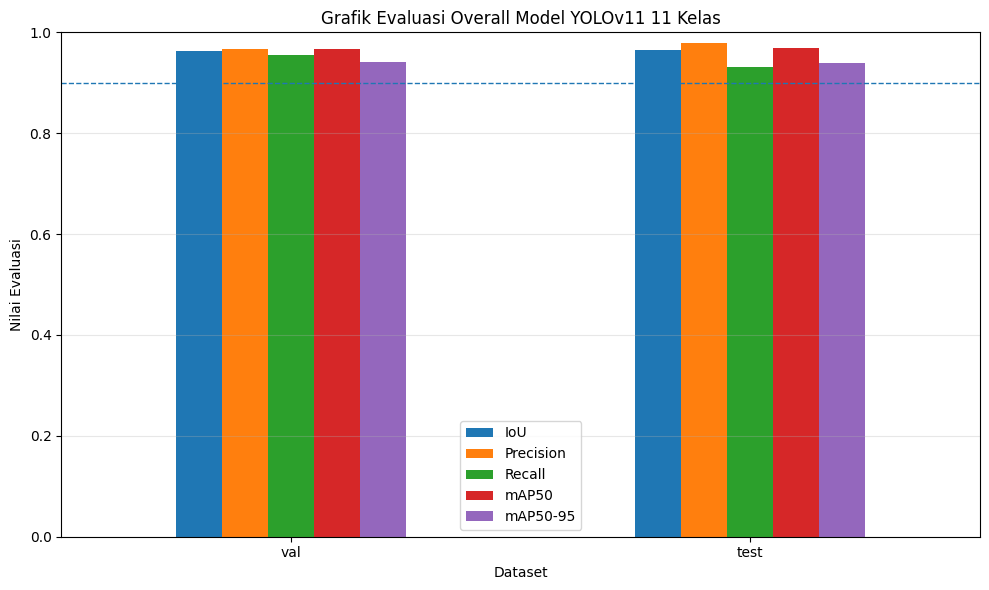

Grafik evaluasi overall tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/grafik_evaluasi_overall.png


In [ ]:
# Cell 19 — Grafik Evaluasi Overall
plot_df = overall_df.set_index("Dataset")[
    [
        "IoU",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ]
]

ax = plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Grafik Evaluasi Overall Model YOLOv11 11 Kelas")
plt.xlabel("Dataset")
plt.ylabel("Nilai Evaluasi")
plt.ylim(0, 1)
plt.axhline(y=0.90, linestyle="--", linewidth=1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

overall_graph_path = ARTIFACT_DIR / "grafik_evaluasi_overall.png"
plt.savefig(overall_graph_path, dpi=300)
plt.show()

print("Grafik evaluasi overall tersimpan di:", overall_graph_path)

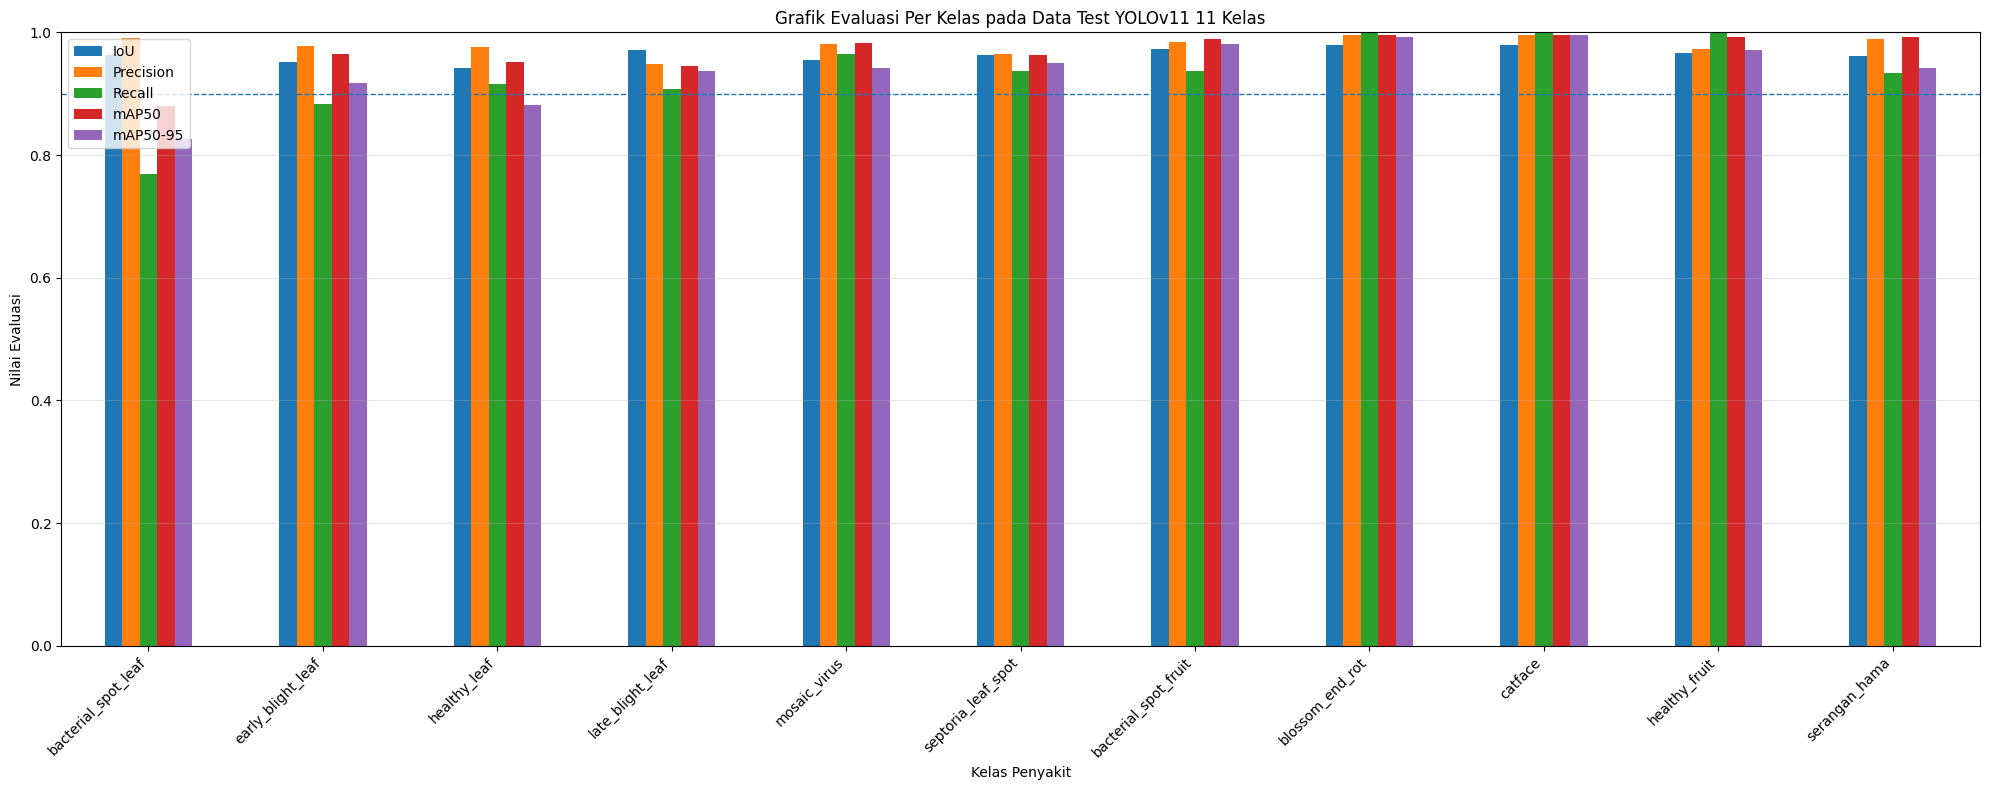

Grafik evaluasi per kelas test tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/grafik_evaluasi_perkelas_test.png


In [ ]:
# Cell 20 — Grafik Evaluasi Per Kelas Data Test
test_class_df = per_class_metrics_df[per_class_metrics_df["Dataset"] == "test"].copy()

test_class_plot = test_class_df.set_index("class_name")[
    [
        "IoU",
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ]
]

ax = test_class_plot.plot(kind="bar", figsize=(20, 8))

plt.title("Grafik Evaluasi Per Kelas pada Data Test YOLOv11 11 Kelas")
plt.xlabel("Kelas Penyakit")
plt.ylabel("Nilai Evaluasi")
plt.ylim(0, 1)
plt.axhline(y=0.90, linestyle="--", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

per_class_graph_path = ARTIFACT_DIR / "grafik_evaluasi_perkelas_test.png"
plt.savefig(per_class_graph_path, dpi=300)
plt.show()

print("Grafik evaluasi per kelas test tersimpan di:", per_class_graph_path)

In [ ]:
# Cell 21 — Analisis RGB Per Objek dan Per Kelas
from PIL import Image
import numpy as np
import pandas as pd

rgb_rows = []

for split in ["train", "val", "test"]:
    image_dir = dataset_path / "images" / split
    label_dir = dataset_path / "labels" / split

    for label_path in label_dir.glob("*.txt"):
        image_path = find_image_by_stem(image_dir, label_path.stem)

        if image_path is None:
            continue

        with Image.open(image_path) as img:
            img = img.convert("RGB")
            img_array = np.array(img)
            img_height, img_width, _ = img_array.shape

        with open(label_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))

            if class_id < 0 or class_id >= len(class_names):
                print(f"Class ID tidak valid pada file {label_path}: {class_id}")
                continue

            x_center = float(parts[1])
            y_center = float(parts[2])
            box_width = float(parts[3])
            box_height = float(parts[4])

            x1 = int((x_center - box_width / 2) * img_width)
            y1 = int((y_center - box_height / 2) * img_height)
            x2 = int((x_center + box_width / 2) * img_width)
            y2 = int((y_center + box_height / 2) * img_height)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img_width, x2)
            y2 = min(img_height, y2)

            if x2 <= x1 or y2 <= y1:
                continue

            roi = img_array[y1:y2, x1:x2]
            mean_rgb = roi.reshape(-1, 3).mean(axis=0)

            rgb_rows.append({
                "split": split,
                "image": image_path.name,
                "class_id": class_id,
                "class_name": class_names[class_id],
                "mean_R": mean_rgb[0],
                "mean_G": mean_rgb[1],
                "mean_B": mean_rgb[2]
            })

rgb_df = pd.DataFrame(rgb_rows)

if len(rgb_df) == 0:
    raise ValueError("Data RGB kosong. Cek apakah gambar dan label tersedia.")

rgb_summary = rgb_df.groupby("class_name")[["mean_R", "mean_G", "mean_B"]].mean().reset_index()

print("Detail RGB:")
display(rgb_df.head())

print("Ringkasan RGB per kelas:")
display(rgb_summary)

rgb_detail_path = ARTIFACT_DIR / "rgb_analysis_detail.csv"
rgb_summary_path = ARTIFACT_DIR / "rgb_analysis_summary_per_class.csv"

rgb_df.to_csv(rgb_detail_path, index=False)
rgb_summary.to_csv(rgb_summary_path, index=False)

print("RGB detail tersimpan di:", rgb_detail_path)
print("RGB summary tersimpan di:", rgb_summary_path)

Detail RGB:


,split,image,class_id,class_name,mean_R,mean_G,mean_B
0,train,septoria_leaf_spot_01330.jpg,5,septoria_leaf_spot,146.483036,151.567104,146.734383
1,train,serangan_hama_02353.jpg,10,serangan_hama,132.886992,111.285789,72.457695
2,train,hardaug_early_blight_leaf_00219_hflip_early_bl...,1,early_blight_leaf,113.207297,116.699528,70.589637
3,train,hardaug_late_blight_leaf_00282_brightness_late...,3,late_blight_leaf,102.989656,103.091609,72.759524
4,train,healthy_fruit_02178.jpg,9,healthy_fruit,153.010097,157.490759,114.193240


Ringkasan RGB per kelas:


,class_name,mean_R,mean_G,mean_B
0,bacterial_spot_fruit,126.315861,131.662490,66.087679
1,bacterial_spot_leaf,114.867485,118.930700,74.953828
2,blossom_end_rot,130.585639,109.642829,77.446115
3,catface,123.987361,121.708330,69.997916
4,early_blight_leaf,103.840332,114.243086,82.040902
5,healthy_fruit,143.964110,127.665238,64.832597
6,healthy_leaf,95.038337,116.371673,80.440286
7,late_blight_leaf,116.807453,122.596942,93.130942
8,mosaic_virus,100.597345,119.619904,84.414921
9,septoria_leaf_spot,106.955614,124.784212,101.112260


RGB detail tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/rgb_analysis_detail.csv
RGB summary tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/rgb_analysis_summary_per_class.csv


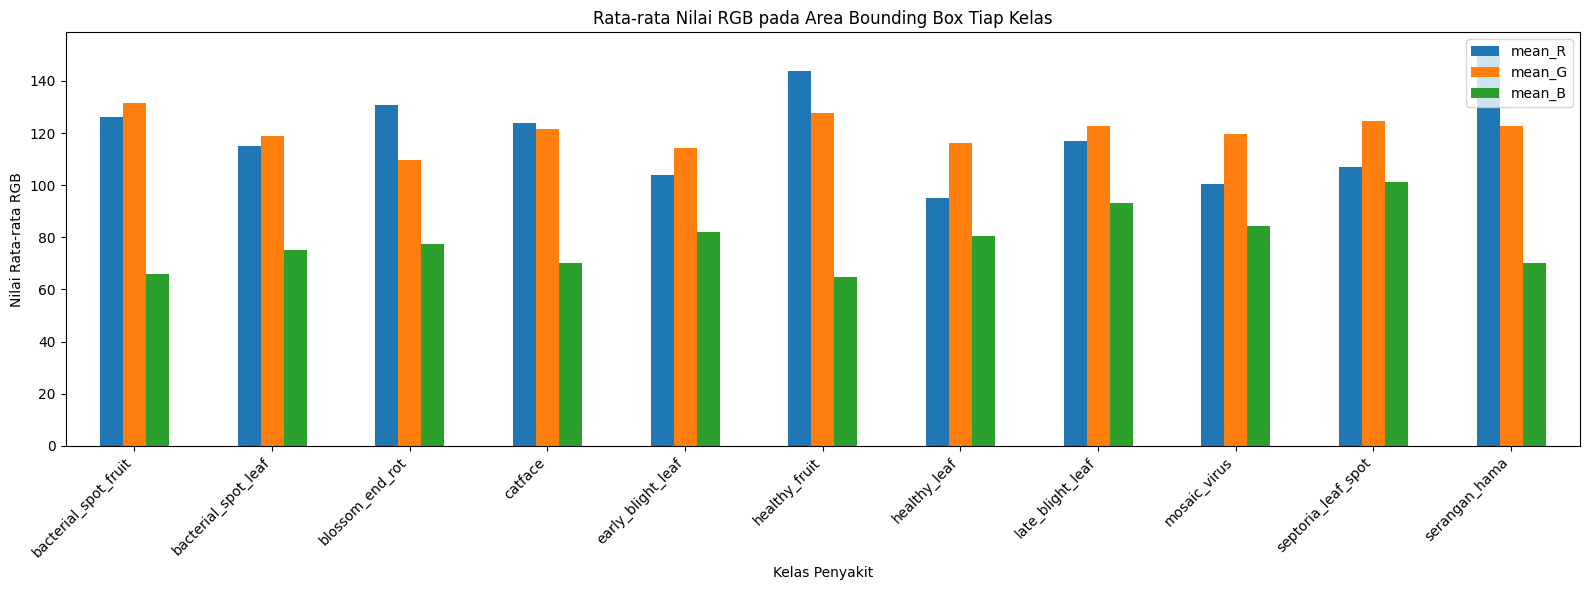

Grafik RGB tersimpan di: /content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/grafik_rgb_per_kelas.png


In [ ]:
# Cell 22 — Grafik RGB Per Kelas
rgb_summary_plot = rgb_summary.set_index("class_name")

ax = rgb_summary_plot[["mean_R", "mean_G", "mean_B"]].plot(
    kind="bar",
    figsize=(16, 6)
)

plt.title("Rata-rata Nilai RGB pada Area Bounding Box Tiap Kelas")
plt.xlabel("Kelas Penyakit")
plt.ylabel("Nilai Rata-rata RGB")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

rgb_graph_path = ARTIFACT_DIR / "grafik_rgb_per_kelas.png"
plt.savefig(rgb_graph_path, dpi=300)
plt.show()

print("Grafik RGB tersimpan di:", rgb_graph_path)

In [ ]:
# Cell 23 — Contoh Visualisasi RGB Satu Gambar Tiap Kelas
from IPython.display import Image as IPyImage, display

rgb_example_dir = ARTIFACT_DIR / "contoh_rgb_perkelas"
rgb_example_dir.mkdir(parents=True, exist_ok=True)

USE_BBOX_CROP = True


def find_sample_for_class(target_class_id):
    for split in ["test", "val", "train"]:
        image_dir = dataset_path / "images" / split
        label_dir = dataset_path / "labels" / split

        for label_path in label_dir.glob("*.txt"):
            image_path = find_image_by_stem(image_dir, label_path.stem)

            if image_path is None:
                continue

            with open(label_path, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()

                    if not line:
                        continue

                    parts = line.split()

                    if len(parts) != 5:
                        continue

                    class_id = int(float(parts[0]))

                    if class_id == target_class_id:
                        return {
                            "split": split,
                            "image_path": image_path,
                            "label_path": label_path,
                            "label_parts": parts
                        }

    return None


def crop_bbox_from_yolo(image_array, label_parts):
    img_height, img_width, _ = image_array.shape

    x_center = float(label_parts[1])
    y_center = float(label_parts[2])
    box_width = float(label_parts[3])
    box_height = float(label_parts[4])

    x1 = int((x_center - box_width / 2) * img_width)
    y1 = int((y_center - box_height / 2) * img_height)
    x2 = int((x_center + box_width / 2) * img_width)
    y2 = int((y_center + box_height / 2) * img_height)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_width, x2)
    y2 = min(img_height, y2)

    if x2 <= x1 or y2 <= y1:
        return image_array

    return image_array[y1:y2, x1:x2]


def create_rgb_visualization_for_class(class_id, class_name):
    sample = find_sample_for_class(class_id)

    if sample is None:
        print(f"Tidak ditemukan sampel untuk kelas: {class_name}")
        return None

    image_path = sample["image_path"]

    with Image.open(image_path) as img:
        img = img.convert("RGB")
        image_array = np.array(img)

    if USE_BBOX_CROP:
        visual_array = crop_bbox_from_yolo(image_array, sample["label_parts"])
        visual_title = f"{class_name}\nROI Bounding Box"
    else:
        visual_array = image_array
        visual_title = f"{class_name}\nFull Image"

    red_channel = visual_array[:, :, 0]
    green_channel = visual_array[:, :, 1]
    blue_channel = visual_array[:, :, 2]

    channels = [
        ("Red", red_channel, "Reds"),
        ("Green", green_channel, "Greens"),
        ("Blue", blue_channel, "Blues")
    ]

    fig, axes = plt.subplots(3, 3, figsize=(12, 9))

    for row_index, (channel_name, channel_data, cmap_name) in enumerate(channels):
        axes[row_index, 0].imshow(visual_array)
        axes[row_index, 0].set_title(f"RGB Image\n{visual_title}")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(channel_data, cmap=cmap_name, vmin=0, vmax=255)
        axes[row_index, 1].set_title(f"{channel_name} Channel")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].hist(channel_data.ravel(), bins=256, range=(0, 255))
        axes[row_index, 2].set_title(f"Histogram {channel_name}")
        axes[row_index, 2].set_xlim(0, 255)

    plt.suptitle(f"Analisis RGB - {class_name}", fontsize=14)
    plt.tight_layout()

    output_path = rgb_example_dir / f"{class_id}_{class_name}_rgb_visualization.png"
    plt.savefig(output_path, dpi=300)
    plt.close()

    return output_path


rgb_visual_paths = []

for class_id, class_name in enumerate(class_names):
    output_path = create_rgb_visualization_for_class(class_id, class_name)

    if output_path is not None:
        rgb_visual_paths.append(output_path)

print("Jumlah visualisasi RGB dibuat:", len(rgb_visual_paths))

for path in rgb_visual_paths:
    print(path)

Jumlah visualisasi RGB dibuat: 11
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/0_bacterial_spot_leaf_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/1_early_blight_leaf_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/2_healthy_leaf_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/3_late_blight_leaf_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/4_mosaic_virus_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/5_septoria_leaf_spot_rgb_visualization.png
/content/YOLO_Tomat_Result/final_yolo11m_tomat_11class_hardaug_v2_artifacts/contoh_rgb_perkelas/6_bacterial_spot_fruit_rgb_visualization.png
/cont

In [ ]:
# Cell 24 — Tampilkan Visualisasi RGB di Colab
for path in rgb_visual_paths:
    display(IPyImage(filename=str(path)))

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Cell 25 — Prediksi Gambar Test dan Simpan ke Colab
predict_results = model.predict(
    source=str(dataset_path / "images" / "test"),
    imgsz=IMGSZ,
    conf=0.25,
    save=True,
    project=str(RESULT_DIR),
    name=f"predict_test_{RUN_NAME}",
    exist_ok=True
)

predict_dir = RESULT_DIR / f"predict_test_{RUN_NAME}"

print("Hasil prediksi test tersimpan di:")
print(predict_dir)

Results saved to /content/YOLO_Tomat_Result/predict_test_final_yolo11m_tomat_11class_hardaug_v2
Hasil prediksi test tersimpan di:
/content/YOLO_Tomat_Result/predict_test_final_yolo11m_tomat_11class_hardaug_v2


In [ ]:
# Cell 25B — Bersihkan Disk Sebelum Membuat ZIP
from pathlib import Path
import shutil

print("Cek disk sebelum pembersihan:")
!df -h

# Dataset hasil extract aman dihapus setelah training, evaluasi, RGB, dan prediksi selesai
dataset_extract_dir = Path("/content/tomat_dataset")

if dataset_extract_dir.exists():
    shutil.rmtree(dataset_extract_dir)
    print("Folder dataset hasil extract sudah dihapus:", dataset_extract_dir)
else:
    print("Folder dataset hasil extract tidak ditemukan atau sudah terhapus.")

# Bersihkan cache yang tidak penting
!rm -rf /root/.cache/pip
!rm -rf /root/.cache/torch
!rm -rf /root/.config/Ultralytics

print("\nCek disk setelah pembersihan:")
!df -h

Cek disk sebelum pembersihan:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   86G   28G  76% /
tmpfs            64M     0   64M   0% /dev
shm              87G  196K   87G   1% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/nvme0n1p1  119G  113G  6.3G  95% /opt/bin/.nvidia
tmpfs            89G  952K   89G   1% /var/colab
tmpfs            89G     0   89G   0% /proc/acpi
tmpfs            89G     0   89G   0% /proc/scsi
tmpfs            89G     0   89G   0% /sys/firmware
drive           113G   87G   26G  78% /content/drive
Folder dataset hasil extract sudah dihapus: /content/tomat_dataset

Cek disk setelah pembersihan:
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   72G   41G  64% /
tmpfs            64M     0   64M   0% /dev
shm              87G  196K   87G   1% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/nvme0n1p1  119G  113G  6.3G  95% /opt/bin/.nvidia
tmpfs            89G  952K   89G

In [ ]:
# Cell 26 — Buat ZIP Final di Colab
final_zip_path = Path(f"/content/hasil_final_{RUN_NAME}.zip")

if final_zip_path.exists():
    final_zip_path.unlink()

with zipfile.ZipFile(final_zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    # Masukkan semua artifact utama
    for file_path in ARTIFACT_DIR.rglob("*"):
        if file_path.is_file():
            arcname = file_path.relative_to(ARTIFACT_DIR)
            zipf.write(file_path, arcname=arcname)

    # Masukkan hasil prediksi test
    if predict_dir.exists():
        for file_path in predict_dir.rglob("*"):
            if file_path.is_file():
                arcname = Path("predict_test") / file_path.relative_to(predict_dir)
                zipf.write(file_path, arcname=arcname)

    # Masukkan output training penting
    training_results_dir = RUN_DIR

    if training_results_dir.exists():
        important_files = [
            "results.csv",
            "results.png",
            "confusion_matrix.png",
            "confusion_matrix_normalized.png",
            "PR_curve.png",
            "F1_curve.png",
            "P_curve.png",
            "R_curve.png",
            "labels.jpg",
            "labels_correlogram.jpg",
            "train_batch0.jpg",
            "train_batch1.jpg",
            "train_batch2.jpg",
            "val_batch0_labels.jpg",
            "val_batch0_pred.jpg",
            "val_batch1_labels.jpg",
            "val_batch1_pred.jpg",
            "val_batch2_labels.jpg",
            "val_batch2_pred.jpg"
        ]

        for important_name in important_files:
            source_file = training_results_dir / important_name
            if source_file.exists():
                zipf.write(source_file, arcname=Path("training_outputs") / important_name)

print("ZIP final tersimpan di Colab:")
print(final_zip_path)
print("Ukuran ZIP final:", round(final_zip_path.stat().st_size / (1024**2), 2), "MB")

ZIP final tersimpan di Colab:
/content/hasil_final_final_yolo11m_tomat_11class_hardaug_v2.zip
Ukuran ZIP final: 943.92 MB


In [ ]:
# Cell 27 — Cek Isi ZIP Final
with zipfile.ZipFile(final_zip_path, "r") as zipf:
    file_list = zipf.namelist()

print("Jumlah file dalam ZIP:", len(file_list))

for item in file_list[:80]:
    print(item)

print("\nLokasi ZIP final:")
print(final_zip_path)

Jumlah file dalam ZIP: 370
hasil_evaluasi_manual_overall.csv
rgb_analysis_detail.csv
cek_target_90_persen_perkelas_test.csv
best.pt
hasil_evaluasi_overall.csv
grafik_evaluasi_perkelas_test.png
rgb_analysis_summary_per_class.csv
cek_target_90_persen_overall.csv
last.pt
hasil_evaluasi_manual_perkelas.csv
hasil_evaluasi_perkelas.csv
hasil_evaluasi_manual_detail_ap.csv
perbandingan_evaluasi_awal_vs_manual.csv
grafik_rgb_per_kelas.png
grafik_evaluasi_overall.png
contoh_rgb_perkelas/2_healthy_leaf_rgb_visualization.png
contoh_rgb_perkelas/0_bacterial_spot_leaf_rgb_visualization.png
contoh_rgb_perkelas/5_septoria_leaf_spot_rgb_visualization.png
contoh_rgb_perkelas/10_serangan_hama_rgb_visualization.png
contoh_rgb_perkelas/1_early_blight_leaf_rgb_visualization.png
contoh_rgb_perkelas/9_healthy_fruit_rgb_visualization.png
contoh_rgb_perkelas/6_bacterial_spot_fruit_rgb_visualization.png
contoh_rgb_perkelas/3_late_blight_leaf_rgb_visualization.png
contoh_rgb_perkelas/8_catface_rgb_visualization.p

In [34]:
# Cell 28 — Download ZIP Final ke Laptop
from google.colab import files

files.download(str(final_zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
# Cell 29 — Cek File Penting di ZIP
required_files = [
    "best.pt",
    "last.pt",
    "hasil_evaluasi_overall.csv",
    "hasil_evaluasi_perkelas.csv",
    "cek_target_90_persen_overall.csv",
    "cek_target_90_persen_perkelas_test.csv",
    "grafik_evaluasi_overall.png",
    "grafik_evaluasi_perkelas_test.png",
    "rgb_analysis_detail.csv",
    "rgb_analysis_summary_per_class.csv",
    "grafik_rgb_per_kelas.png"
]

with zipfile.ZipFile(final_zip_path, "r") as zipf:
    zip_items = zipf.namelist()

print("Cek file penting:")

for file_name in required_files:
    status = "ADA" if file_name in zip_items else "TIDAK ADA"
    print(f"{file_name}: {status}")

Cek file penting:
best.pt: ADA
last.pt: ADA
hasil_evaluasi_overall.csv: ADA
hasil_evaluasi_perkelas.csv: ADA
cek_target_90_persen_overall.csv: ADA
cek_target_90_persen_perkelas_test.csv: ADA
grafik_evaluasi_overall.png: ADA
grafik_evaluasi_perkelas_test.png: ADA
rgb_analysis_detail.csv: ADA
rgb_analysis_summary_per_class.csv: ADA
grafik_rgb_per_kelas.png: ADA


In [13]:
# LANGKAH 1 — Instal Ultralytics
!pip install -q ultralytics

In [14]:
# LANGKAH 2 — Mount Drive dan konfigurasi
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import subprocess
import numpy as np
import pandas as pd
import torch
from IPython.display import display

ZIP_PATH = Path("/content/drive/MyDrive/Colab Notebooks/Dataset_Tomat_YOLO.zip")
BEST_MODEL_PATH = Path("/content/drive/MyDrive/Colab Notebooks/best.pt")
WORK_DIR = Path("/content/tomat_dataset")

# Hasil disimpan langsung ke Drive agar tidak hilang saat runtime terputus.
ARTIFACT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Hasil_Evaluasi_Manual_Tomat"
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

IMGSZ = 832
EVAL_DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("ZIP tersedia   :", ZIP_PATH.exists())
print("best.pt tersedia:", BEST_MODEL_PATH.exists())
print("Device evaluasi :", EVAL_DEVICE)
print("Folder hasil    :", ARTIFACT_DIR)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP dataset tidak ditemukan: {ZIP_PATH}")

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"best.pt tidak ditemukan: {BEST_MODEL_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP tersedia   : True
best.pt tersedia: True
Device evaluasi : cpu
Folder hasil    : /content/drive/MyDrive/Colab Notebooks/Hasil_Evaluasi_Manual_Tomat


In [15]:
# LANGKAH 3 — Ekstrak dan temukan dataset YOLO
def find_yolo_dataset(root_dir):
    candidates = [root_dir]
    candidates.extend(path for path in root_dir.rglob("*") if path.is_dir())

    for path in candidates:
        if (
            (path / "data.yaml").exists()
            and (path / "images").exists()
            and (path / "labels").exists()
        ):
            return path
    return None


dataset_path = find_yolo_dataset(WORK_DIR) if WORK_DIR.exists() else None

if dataset_path is None:
    if WORK_DIR.exists():
        shutil.rmtree(WORK_DIR)

    WORK_DIR.mkdir(parents=True, exist_ok=True)

    print("Mengekstrak dataset. Tunggu sampai selesai...")
    subprocess.run(
        ["unzip", "-q", "-o", str(ZIP_PATH), "-d", str(WORK_DIR)],
        check=True
    )

    dataset_path = find_yolo_dataset(WORK_DIR)

if dataset_path is None:
    raise FileNotFoundError(
        "Struktur YOLO tidak ditemukan: data.yaml, images, dan labels."
    )

data_yaml_path = dataset_path / "data.yaml"

val_image_count = sum(
    1 for path in (dataset_path / "images" / "val").glob("*") if path.is_file()
)
test_image_count = sum(
    1 for path in (dataset_path / "images" / "test").glob("*") if path.is_file()
)
val_label_count = len(list((dataset_path / "labels" / "val").glob("*.txt")))
test_label_count = len(list((dataset_path / "labels" / "test").glob("*.txt")))

print("Dataset ditemukan:", dataset_path)
print("Gambar val       :", val_image_count)
print("Label val        :", val_label_count)
print("Gambar test      :", test_image_count)
print("Label test       :", test_label_count)

if val_image_count == 0 or test_image_count == 0:
    raise FileNotFoundError("Folder images/val atau images/test kosong.")


Dataset ditemukan: /content/tomat_dataset
Gambar val       : 319
Label val        : 319
Gambar test      : 330
Label test       : 330


In [16]:
# LANGKAH 4 — Muat best.pt tanpa training ulang
from ultralytics import YOLO

model = YOLO(str(BEST_MODEL_PATH))

if isinstance(model.names, dict):
    class_names = [model.names[index] for index in sorted(model.names)]
else:
    class_names = list(model.names)

print("Model best.pt berhasil dimuat.")
print("Jumlah kelas:", len(class_names))

for class_id, class_name in enumerate(class_names):
    print(f"{class_id}: {class_name}")


Model best.pt berhasil dimuat.
Jumlah kelas: 11
0: bacterial_spot_leaf
1: early_blight_leaf
2: healthy_leaf
3: late_blight_leaf
4: mosaic_virus
5: septoria_leaf_spot
6: bacterial_spot_fruit
7: blossom_end_rot
8: catface
9: healthy_fruit
10: serangan_hama


In [17]:
# LANGKAH 5 — Fungsi Perhitungan Manual IoU, Precision, Recall, mAP50, mAP50-95
from pathlib import Path
from PIL import Image
from collections import defaultdict
import numpy as np
import pandas as pd

MANUAL_CONF_THRESHOLD = 0.70
MANUAL_IOU_THRESHOLD = 0.50
MANUAL_PREDICTION_CONF = 0.001
MANUAL_AP_IOU_THRESHOLDS = np.round(np.arange(0.50, 0.96, 0.05), 2)


IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]


def yolo_to_xyxy(x_center, y_center, box_width, box_height, img_width, img_height):
    """Konversi bbox YOLO ternormalisasi menjadi koordinat piksel [x1, y1, x2, y2]."""
    x1 = (x_center - box_width / 2.0) * img_width
    y1 = (y_center - box_height / 2.0) * img_height
    x2 = (x_center + box_width / 2.0) * img_width
    y2 = (y_center + box_height / 2.0) * img_height
    return np.array([x1, y1, x2, y2], dtype=np.float32)


def box_iou(box_a, box_b):
    """Menghitung IoU dua bounding box format [x1, y1, x2, y2]."""
    x_left = max(float(box_a[0]), float(box_b[0]))
    y_top = max(float(box_a[1]), float(box_b[1]))
    x_right = min(float(box_a[2]), float(box_b[2]))
    y_bottom = min(float(box_a[3]), float(box_b[3]))

    intersection_width = max(0.0, x_right - x_left)
    intersection_height = max(0.0, y_bottom - y_top)
    intersection_area = intersection_width * intersection_height

    area_a = max(0.0, float(box_a[2]) - float(box_a[0])) * max(
        0.0, float(box_a[3]) - float(box_a[1])
    )
    area_b = max(0.0, float(box_b[2]) - float(box_b[0])) * max(
        0.0, float(box_b[3]) - float(box_b[1])
    )

    union_area = area_a + area_b - intersection_area
    return 0.0 if union_area <= 0.0 else float(intersection_area / union_area)


def manual_safe_divide(numerator, denominator):
    """Pembagian aman untuk menghindari ZeroDivisionError."""
    if denominator == 0:
        return np.nan
    return float(numerator / denominator)


def manual_read_ground_truth(image_path, label_path):
    """
    Membaca label YOLO:
    class_id x_center y_center width height
    lalu mengubahnya menjadi koordinat piksel [x1, y1, x2, y2].
    """
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    ground_truths = []

    if not label_path.exists():
        return ground_truths

    with open(label_path, "r", encoding="utf-8") as file:
        for line in file:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))

            if class_id < 0 or class_id >= len(class_names):
                continue

            x_center = float(parts[1])
            y_center = float(parts[2])
            box_width = float(parts[3])
            box_height = float(parts[4])

            box_xyxy = yolo_to_xyxy(
                x_center,
                y_center,
                box_width,
                box_height,
                img_width,
                img_height
            )

            # Batasi koordinat agar tetap berada di dalam gambar.
            box_xyxy[0] = np.clip(box_xyxy[0], 0, img_width)
            box_xyxy[1] = np.clip(box_xyxy[1], 0, img_height)
            box_xyxy[2] = np.clip(box_xyxy[2], 0, img_width)
            box_xyxy[3] = np.clip(box_xyxy[3], 0, img_height)

            ground_truths.append({
                "class_id": class_id,
                "box": box_xyxy
            })

    return ground_truths


def manual_collect_split_data(split_name):
    """
    Mengumpulkan ground truth dan prediksi untuk satu split.

    Prediksi dilakukan per gambar agar setiap hasil prediksi
    pasti dipasangkan dengan ground truth dari gambar yang sama.
    """
    image_dir = dataset_path / "images" / split_name
    label_dir = dataset_path / "labels" / split_name

    image_paths = []

    for extension in IMAGE_EXTENSIONS:
        image_paths.extend(image_dir.glob(f"*{extension}"))
        image_paths.extend(image_dir.glob(f"*{extension.upper()}"))

    image_paths = sorted(
        set(image_paths),
        key=lambda path: path.name.lower()
    )

    if len(image_paths) == 0:
        raise FileNotFoundError(
            f"Tidak ada gambar pada split: {split_name}"
        )

    gt_by_image = {}
    pred_by_image = {}

    for image_index, image_path in enumerate(image_paths, start=1):
        # Kunci yang sama digunakan untuk GT dan prediksi
        image_key = image_path.name
        label_path = label_dir / f"{image_path.stem}.txt"

        # Membaca ground truth
        gt_by_image[image_key] = manual_read_ground_truth(
            image_path=image_path,
            label_path=label_path
        )

        pred_by_image[image_key] = []

        # Prediksi dilakukan per gambar agar image_key tidak berubah
        prediction_results = model.predict(
            source=str(image_path),
            imgsz=IMGSZ,
            conf=MANUAL_PREDICTION_CONF,
            iou=0.70,
            max_det=300,
            device=EVAL_DEVICE,
            verbose=False
        )

        result = prediction_results[0]

        if result.boxes is not None and len(result.boxes) > 0:
            boxes_xyxy = (
                result.boxes.xyxy
                .detach()
                .cpu()
                .numpy()
            )

            confidences = (
                result.boxes.conf
                .detach()
                .cpu()
                .numpy()
            )

            class_ids = (
                result.boxes.cls
                .detach()
                .cpu()
                .numpy()
                .astype(int)
            )

            for box_xyxy, confidence, class_id in zip(
                boxes_xyxy,
                confidences,
                class_ids
            ):
                if class_id < 0 or class_id >= len(class_names):
                    continue

                pred_by_image[image_key].append({
                    "class_id": int(class_id),
                    "confidence": float(confidence),
                    "box": box_xyxy.astype(np.float32)
                })

        if image_index % 50 == 0 or image_index == len(image_paths):
            print(
                f"{split_name}: "
                f"{image_index}/{len(image_paths)} gambar selesai"
            )

    # Pemeriksaan bahwa seluruh kunci gambar sesuai
    gt_keys = set(gt_by_image.keys())
    pred_keys = set(pred_by_image.keys())

    print(f"\nPemeriksaan split {split_name}:")
    print("Jumlah gambar GT       :", len(gt_keys))
    print("Jumlah gambar prediksi :", len(pred_keys))
    print("Kunci gambar sama      :", gt_keys == pred_keys)

    if gt_keys != pred_keys:
        print(
            "Prediksi tanpa GT:",
            list(pred_keys - gt_keys)[:10]
        )
        print(
            "GT tanpa prediksi:",
            list(gt_keys - pred_keys)[:10]
        )

    return gt_by_image, pred_by_image


def manual_match_one_class(
    gt_by_image,
    pred_by_image,
    class_id,
    iou_threshold,
    confidence_threshold
):
    """
    Mencocokkan prediksi dan ground truth untuk satu kelas.

    Urutan prediksi dibuat dari confidence tertinggi ke terendah.
    Satu ground truth hanya boleh dipasangkan dengan satu prediksi.
    """
    gt_boxes_by_image = {}
    total_gt = 0

    for image_key, ground_truths in gt_by_image.items():
        class_boxes = [
            item["box"]
            for item in ground_truths
            if item["class_id"] == class_id
        ]

        gt_boxes_by_image[image_key] = class_boxes
        total_gt += len(class_boxes)

    predictions = []

    for image_key, prediction_items in pred_by_image.items():
        for item in prediction_items:
            if (
                item["class_id"] == class_id
                and item["confidence"] >= confidence_threshold
            ):
                predictions.append({
                    "image_key": image_key,
                    "confidence": item["confidence"],
                    "box": item["box"]
                })

    predictions.sort(key=lambda item: item["confidence"], reverse=True)

    used_gt_indices = defaultdict(set)

    tp_flags = np.zeros(len(predictions), dtype=np.float64)
    fp_flags = np.zeros(len(predictions), dtype=np.float64)
    matched_ious = np.full(len(predictions), np.nan, dtype=np.float64)

    for prediction_index, prediction in enumerate(predictions):
        image_key = prediction["image_key"]
        predicted_box = prediction["box"]
        candidate_gt_boxes = gt_boxes_by_image.get(image_key, [])

        best_iou = 0.0
        best_gt_index = None

        for gt_index, gt_box in enumerate(candidate_gt_boxes):
            if gt_index in used_gt_indices[image_key]:
                continue

            current_iou = box_iou(predicted_box, gt_box)

            if current_iou > best_iou:
                best_iou = current_iou
                best_gt_index = gt_index

        if best_gt_index is not None and best_iou >= iou_threshold:
            tp_flags[prediction_index] = 1.0
            matched_ious[prediction_index] = best_iou
            used_gt_indices[image_key].add(best_gt_index)
        else:
            fp_flags[prediction_index] = 1.0

    confidences = np.array(
        [item["confidence"] for item in predictions],
        dtype=np.float64
    )

    return {
        "total_gt": total_gt,
        "total_predictions": len(predictions),
        "confidences": confidences,
        "tp_flags": tp_flags,
        "fp_flags": fp_flags,
        "matched_ious": matched_ious
    }


def manual_compute_ap_101_point(tp_flags, fp_flags, total_gt):
    """
    Menghitung AP dengan interpolasi Precision–Recall 101 titik.
    Fungsi ini tidak menggunakan metrics.box milik Ultralytics.
    """
    if total_gt == 0:
        return np.nan, np.array([]), np.array([])

    if len(tp_flags) == 0:
        return 0.0, np.array([]), np.array([])

    cumulative_tp = np.cumsum(tp_flags)
    cumulative_fp = np.cumsum(fp_flags)

    recall_curve = cumulative_tp / total_gt
    precision_curve = cumulative_tp / np.maximum(
        cumulative_tp + cumulative_fp,
        np.finfo(np.float64).eps
    )

    # Precision envelope: precision tidak boleh meningkat saat recall meningkat.
    precision_envelope = np.maximum.accumulate(precision_curve[::-1])[::-1]

    recall_points = np.linspace(0.0, 1.0, 101)
    interpolated_precision = []

    for recall_level in recall_points:
        valid_indices = np.where(recall_curve >= recall_level)[0]

        if len(valid_indices) == 0:
            interpolated_precision.append(0.0)
        else:
            interpolated_precision.append(
                float(np.max(precision_envelope[valid_indices]))
            )

    average_precision = float(np.mean(interpolated_precision))

    return average_precision, precision_curve, recall_curve


def manual_evaluate_split(split_name):
    """
    Menghitung seluruh metrik secara manual untuk satu split dataset.
    """
    print(f"\nMengumpulkan ground truth dan prediksi manual: {split_name}")

    gt_by_image, pred_by_image = manual_collect_split_data(split_name)

    per_class_rows = []
    ap_detail_rows = []

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_gt = 0
    total_predictions = 0
    all_matched_ious = []

    for class_id, class_name in enumerate(class_names):
        # Titik operasi tetap untuk IoU, Precision, dan Recall.
        operating_result = manual_match_one_class(
            gt_by_image=gt_by_image,
            pred_by_image=pred_by_image,
            class_id=class_id,
            iou_threshold=MANUAL_IOU_THRESHOLD,
            confidence_threshold=MANUAL_CONF_THRESHOLD
        )

        class_tp = int(np.sum(operating_result["tp_flags"]))
        class_fp = int(np.sum(operating_result["fp_flags"]))
        class_gt = int(operating_result["total_gt"])
        class_fn = int(class_gt - class_tp)
        class_predictions = int(operating_result["total_predictions"])

        valid_matched_ious = operating_result["matched_ious"][
            ~np.isnan(operating_result["matched_ious"])
        ]

        class_iou_sum = float(np.sum(valid_matched_ious))
        class_mean_iou = (
            float(np.mean(valid_matched_ious))
            if len(valid_matched_ious) > 0
            else np.nan
        )

        class_precision = manual_safe_divide(
            class_tp,
            class_tp + class_fp
        )
        class_recall = manual_safe_divide(
            class_tp,
            class_tp + class_fn
        )

        class_ap_values = []

        for ap_iou_threshold in MANUAL_AP_IOU_THRESHOLDS:
            ranked_result = manual_match_one_class(
                gt_by_image=gt_by_image,
                pred_by_image=pred_by_image,
                class_id=class_id,
                iou_threshold=float(ap_iou_threshold),
                confidence_threshold=MANUAL_PREDICTION_CONF
            )

            average_precision, _, _ = manual_compute_ap_101_point(
                tp_flags=ranked_result["tp_flags"],
                fp_flags=ranked_result["fp_flags"],
                total_gt=ranked_result["total_gt"]
            )

            class_ap_values.append(average_precision)

            ap_detail_rows.append({
                "Dataset": split_name,
                "class_id": class_id,
                "class_name": class_name,
                "IoU_threshold": float(ap_iou_threshold),
                "AP": average_precision,
                "GT": class_gt
            })

        class_ap50 = class_ap_values[0]
        class_map50_95 = (
            float(np.nanmean(class_ap_values))
            if class_gt > 0
            else np.nan
        )

        per_class_rows.append({
            "Dataset": split_name,
            "class_id": class_id,
            "class_name": class_name,
            "GT": class_gt,
            "Predictions": class_predictions,
            "TP": class_tp,
            "FP": class_fp,
            "FN": class_fn,
            "sum_IoU_TP": class_iou_sum,
            "IoU": class_mean_iou,
            "Precision": class_precision,
            "Recall": class_recall,
            "mAP50": class_ap50,
            "mAP50-95": class_map50_95
        })

        total_tp += class_tp
        total_fp += class_fp
        total_fn += class_fn
        total_gt += class_gt
        total_predictions += class_predictions
        all_matched_ious.extend(valid_matched_ious.tolist())

    per_class_df = pd.DataFrame(per_class_rows)
    ap_detail_df = pd.DataFrame(ap_detail_rows)

    overall_iou_sum = float(np.sum(all_matched_ious))
    overall_mean_iou = (
        float(np.mean(all_matched_ious))
        if len(all_matched_ious) > 0
        else np.nan
    )

    overall_row = {
        "Dataset": split_name,
        "GT": total_gt,
        "Predictions": total_predictions,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "sum_IoU_TP": overall_iou_sum,
        "IoU": overall_mean_iou,
        "Precision": manual_safe_divide(total_tp, total_tp + total_fp),
        "Recall": manual_safe_divide(total_tp, total_tp + total_fn),
        "mAP50": float(per_class_df["mAP50"].mean(skipna=True)),
        "mAP50-95": float(per_class_df["mAP50-95"].mean(skipna=True))
    }

    return overall_row, per_class_df, ap_detail_df


In [19]:
# LANGKAH 6 — Jalankan evaluasi manual dan simpan ke Google Drive
manual_overall_rows = []
manual_per_class_frames = []
manual_ap_detail_frames = []

for split_name in ["val", "test"]:
    (
        manual_overall_row,
        manual_per_class_split_df,
        manual_ap_detail_split_df
    ) = manual_evaluate_split(split_name)

    manual_overall_rows.append(manual_overall_row)
    manual_per_class_frames.append(manual_per_class_split_df)
    manual_ap_detail_frames.append(manual_ap_detail_split_df)

    # Simpan hasil sementara setelah setiap split.
    pd.DataFrame(manual_overall_rows).to_csv(
        ARTIFACT_DIR / "hasil_evaluasi_manual_overall_sementara.csv",
        index=False
    )
    pd.concat(manual_per_class_frames, ignore_index=True).to_csv(
        ARTIFACT_DIR / "hasil_evaluasi_manual_perkelas_sementara.csv",
        index=False
    )
    pd.concat(manual_ap_detail_frames, ignore_index=True).to_csv(
        ARTIFACT_DIR / "hasil_evaluasi_manual_detail_ap_sementara.csv",
        index=False
    )

manual_overall_df = pd.DataFrame(manual_overall_rows)
manual_per_class_df = pd.concat(manual_per_class_frames, ignore_index=True)
manual_ap_detail_df = pd.concat(manual_ap_detail_frames, ignore_index=True)

manual_overall_path = ARTIFACT_DIR / "hasil_evaluasi_manual_overall.csv"
manual_per_class_path = ARTIFACT_DIR / "hasil_evaluasi_manual_perkelas.csv"
manual_ap_detail_path = ARTIFACT_DIR / "hasil_evaluasi_manual_detail_ap.csv"

manual_overall_df.to_csv(manual_overall_path, index=False)
manual_per_class_df.to_csv(manual_per_class_path, index=False)
manual_ap_detail_df.to_csv(manual_ap_detail_path, index=False)

print("\nHasil evaluasi MANUAL keseluruhan:")
display(manual_overall_df)

print("\nHasil evaluasi MANUAL per kelas:")
display(manual_per_class_df)

print("\nFile tersimpan permanen di Google Drive:")
print(manual_overall_path)
print(manual_per_class_path)
print(manual_ap_detail_path)



Mengumpulkan ground truth dan prediksi manual: val
val: 50/319 gambar selesai
val: 100/319 gambar selesai
val: 150/319 gambar selesai
val: 200/319 gambar selesai
val: 250/319 gambar selesai
val: 300/319 gambar selesai
val: 319/319 gambar selesai

Pemeriksaan split val:
Jumlah gambar GT       : 319
Jumlah gambar prediksi : 319
Kunci gambar sama      : True

Mengumpulkan ground truth dan prediksi manual: test
test: 50/330 gambar selesai
test: 100/330 gambar selesai
test: 150/330 gambar selesai
test: 200/330 gambar selesai
test: 250/330 gambar selesai
test: 300/330 gambar selesai
test: 330/330 gambar selesai

Pemeriksaan split test:
Jumlah gambar GT       : 330
Jumlah gambar prediksi : 330
Kunci gambar sama      : True

Hasil evaluasi MANUAL keseluruhan:


,Dataset,GT,Predictions,TP,FP,FN,sum_IoU_TP,IoU,Precision,Recall,mAP50,mAP50-95
0,val,426,412,403,9,23,388.086139,0.962993,0.978155,0.946009,0.968073,0.933756
1,test,423,409,397,12,26,382.536560,0.963568,0.970660,0.938534,0.956445,0.927275



Hasil evaluasi MANUAL per kelas:


,Dataset,class_id,class_name,GT,Predictions,TP,FP,FN,sum_IoU_TP,IoU,Precision,Recall,mAP50,mAP50-95
0,val,0,bacterial_spot_leaf,46,43,43,0,3,40.765772,0.948041,1.000000,0.934783,0.946828,0.871810
1,val,1,early_blight_leaf,52,54,48,6,4,44.825236,0.933859,0.888889,0.923077,0.937477,0.841393
2,val,2,healthy_leaf,54,54,54,0,0,52.264925,0.967869,1.000000,1.000000,1.000000,0.979765
3,val,3,late_blight_leaf,39,34,33,1,6,31.830557,0.964562,0.970588,0.846154,0.885783,0.852952
4,val,4,mosaic_virus,49,44,42,2,7,40.627986,0.967333,0.954545,0.857143,0.881266,0.844266
5,val,5,septoria_leaf_spot,29,28,28,0,1,27.041094,0.965753,1.000000,0.965517,0.997445,0.975992
6,val,6,bacterial_spot_fruit,32,30,30,0,2,29.211646,0.973722,1.000000,0.937500,1.000000,0.963498
7,val,7,blossom_end_rot,29,29,29,0,0,28.416696,0.979886,1.000000,1.000000,1.000000,1.000000
8,val,8,catface,29,29,29,0,0,28.434542,0.980501,1.000000,1.000000,1.000000,1.000000
9,val,9,healthy_fruit,38,38,38,0,0,36.832088,0.969265,1.000000,1.000000,1.000000,0.969258



File tersimpan permanen di Google Drive:
/content/drive/MyDrive/Colab Notebooks/Hasil_Evaluasi_Manual_Tomat/hasil_evaluasi_manual_overall.csv
/content/drive/MyDrive/Colab Notebooks/Hasil_Evaluasi_Manual_Tomat/hasil_evaluasi_manual_perkelas.csv
/content/drive/MyDrive/Colab Notebooks/Hasil_Evaluasi_Manual_Tomat/hasil_evaluasi_manual_detail_ap.csv


In [20]:
# LANGKAH 7 — Tampilkan Perhitungan Manual untuk SETIAP KELAS

for split_name in ["val", "test"]:

    split_df = manual_per_class_df[
        manual_per_class_df["Dataset"] == split_name
    ].copy()

    print("\n" + "=" * 100)
    print(
        f"PERHITUNGAN MANUAL PER KELAS — "
        f"DATASET {split_name.upper()}"
    )
    print("=" * 100)

    for _, row in split_df.iterrows():

        class_id = int(row["class_id"])
        class_name = row["class_name"]

        gt = int(row["GT"])
        predictions = int(row["Predictions"])
        tp = int(row["TP"])
        fp = int(row["FP"])
        fn = int(row["FN"])

        sum_iou = float(row["sum_IoU_TP"])
        mean_iou = row["IoU"]
        precision = row["Precision"]
        recall = row["Recall"]
        ap50 = row["mAP50"]
        ap50_95 = row["mAP50-95"]

        print("\n" + "-" * 100)
        print(f"Kelas {class_id}: {class_name}")
        print("-" * 100)

        print(f"Ground Truth (GT)                    = {gt}")
        print(
            f"Prediksi confidence >= "
            f"{MANUAL_CONF_THRESHOLD}          = {predictions}"
        )
        print(f"True Positive (TP)                   = {tp}")
        print(f"False Positive (FP)                  = {fp}")
        print(f"False Negative (FN)                  = {fn}")

        # =========================================================
        # IoU RATA-RATA PER KELAS
        # =========================================================
        if tp > 0 and not pd.isna(mean_iou):

            print("\nRumus IoU rata-rata per kelas:")
            print(
                "IoU rata-rata = "
                "jumlah IoU seluruh prediksi TP / jumlah TP"
            )
            print(
                f"              = {sum_iou:.6f} / {tp}"
            )
            print(
                f"              = {float(mean_iou):.6f}"
            )

        else:
            print(
                "\nIoU rata-rata tidak dapat dihitung "
                "karena tidak terdapat TP."
            )

        # =========================================================
        # PRECISION PER KELAS
        # =========================================================
        precision_denominator = tp + fp

        print("\nRumus Precision per kelas:")

        if precision_denominator > 0 and not pd.isna(precision):

            print("Precision = TP / (TP + FP)")
            print(
                f"          = {tp} / ({tp} + {fp})"
            )
            print(
                f"          = {tp} / {precision_denominator}"
            )
            print(
                f"          = {float(precision):.6f}"
            )

        else:
            print(
                "Precision tidak dapat dihitung "
                "karena TP + FP = 0."
            )

        # =========================================================
        # RECALL PER KELAS
        # =========================================================
        recall_denominator = tp + fn

        print("\nRumus Recall per kelas:")

        if recall_denominator > 0 and not pd.isna(recall):

            print("Recall = TP / (TP + FN)")
            print(
                f"       = {tp} / ({tp} + {fn})"
            )
            print(
                f"       = {tp} / {recall_denominator}"
            )
            print(
                f"       = {float(recall):.6f}"
            )

        else:
            print(
                "Recall tidak dapat dihitung "
                "karena TP + FN = 0."
            )

        # =========================================================
        # AP50 PER KELAS
        # =========================================================
        print("\nAP50 per kelas:")

        if not pd.isna(ap50):

            print(
                "AP50 = luas kurva Precision–Recall "
                "pada threshold IoU 0.50"
            )
            print(
                f"     = {float(ap50):.6f}"
            )

        else:
            print("AP50 tidak tersedia untuk kelas ini.")

        # =========================================================
        # AP50–95 PER KELAS
        # =========================================================
        class_ap_detail = manual_ap_detail_df[
            (
                manual_ap_detail_df["Dataset"]
                == split_name
            )
            & (
                manual_ap_detail_df["class_id"]
                == class_id
            )
        ].sort_values("IoU_threshold")

        print("\nAP50–95 per kelas:")

        if (
            not class_ap_detail.empty
            and not pd.isna(ap50_95)
        ):

            ap_values = class_ap_detail["AP"].tolist()

            ap_text = " + ".join(
                f"{float(value):.6f}"
                for value in ap_values
            )

            print(
                "AP50–95 kelas = rata-rata AP pada "
                "IoU 0.50, 0.55, ..., 0.95"
            )

            print(
                f"               = ({ap_text}) "
                f"/ {len(ap_values)}"
            )

            print(
                f"               = {float(ap50_95):.6f}"
            )

        else:
            print(
                "AP50–95 tidak tersedia untuk kelas ini."
            )


print("\n" + "=" * 100)
print("KETERANGAN THRESHOLD")
print("=" * 100)

print(
    f"TP, FP, FN, Precision, Recall, dan IoU "
    f"menggunakan confidence >= "
    f"{MANUAL_CONF_THRESHOLD}."
)

print(
    f"Prediksi dinyatakan cocok apabila "
    f"IoU >= {MANUAL_IOU_THRESHOLD} "
    f"dan kelas prediksi sama dengan kelas ground truth."
)

print(
    f"Perhitungan AP menggunakan kandidat prediksi "
    f"mulai confidence {MANUAL_PREDICTION_CONF} "
    f"untuk membentuk kurva Precision–Recall."
)


PERHITUNGAN MANUAL PER KELAS — DATASET VAL

----------------------------------------------------------------------------------------------------
Kelas 0: bacterial_spot_leaf
----------------------------------------------------------------------------------------------------
Ground Truth (GT)                    = 46
Prediksi confidence >= 0.7          = 43
True Positive (TP)                   = 43
False Positive (FP)                  = 0
False Negative (FN)                  = 3

Rumus IoU rata-rata per kelas:
IoU rata-rata = jumlah IoU seluruh prediksi TP / jumlah TP
              = 40.765772 / 43
              = 0.948041

Rumus Precision per kelas:
Precision = TP / (TP + FP)
          = 43 / (43 + 0)
          = 43 / 43
          = 1.000000

Rumus Recall per kelas:
Recall = TP / (TP + FN)
       = 43 / (43 + 3)
       = 43 / 46
       = 0.934783

AP50 per kelas:
AP50 = luas kurva Precision–Recall pada threshold IoU 0.50
     = 0.946828

AP50–95 per kelas:
AP50–95 kelas = rata-rata AP 

In [21]:
check_df = manual_per_class_df.copy()

check_df["Prediksi_Konsisten"] = (
    check_df["Predictions"]
    == check_df["TP"] + check_df["FP"]
)

check_df["GT_Konsisten"] = (
    check_df["GT"]
    == check_df["TP"] + check_df["FN"]
)

display(
    check_df[
        [
            "Dataset",
            "class_name",
            "GT",
            "Predictions",
            "TP",
            "FP",
            "FN",
            "Prediksi_Konsisten",
            "GT_Konsisten"
        ]
    ]
)

,Dataset,class_name,GT,Predictions,TP,FP,FN,Prediksi_Konsisten,GT_Konsisten
0,val,bacterial_spot_leaf,46,43,43,0,3,True,True
1,val,early_blight_leaf,52,54,48,6,4,True,True
2,val,healthy_leaf,54,54,54,0,0,True,True
3,val,late_blight_leaf,39,34,33,1,6,True,True
4,val,mosaic_virus,49,44,42,2,7,True,True
5,val,septoria_leaf_spot,29,28,28,0,1,True,True
6,val,bacterial_spot_fruit,32,30,30,0,2,True,True
7,val,blossom_end_rot,29,29,29,0,0,True,True
8,val,catface,29,29,29,0,0,True,True
9,val,healthy_fruit,38,38,38,0,0,True,True
